# Full Evaluation of Simulations
This notebook contains the full evaluation of all performed simulations.
1. The optimization results are loaded for the different configurations. FXX corresponds to a scheduler step length of XX minutes. GTXX corresponds to a ground-truth data resolution of XX minutes.
2. The results are evaluated based on performance. Relative Performance, Shrinkage and other metrics are calculated.
3. The results are visualized. All result-plots in the paper are produced via this file.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../.."))

import logging
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import re
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import math
import hashlib
import pickle
from IPython.display import display
from evaluation.evaluator import Evaluator
from evaluation.multi_run_evaluator import MultiRunEvaluator


In [2]:
import hashlib
import pickle
from IPython.display import display
from evaluation.evaluator import Evaluator
from evaluation.multi_run_evaluator import MultiRunEvaluator

sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../.."))

F60-GT60 & GT10s

In [3]:
f60_gt60_timestamps = [
    "2026-07-13_16-45",
    "2026-07-10_21-08",
    "2026-07-10_21-15",
]

f60_gt10s_timestamps = [
    "2026-07-24_12-42",
    "2026-07-26_15-36",
    "2026-07-24_12-56",
]


print("F60-GT60 timestamps:")
print(f60_gt60_timestamps)

print("\nF60-GT10s timestamps:")
print(f60_gt10s_timestamps)

F60-GT60 timestamps:
['2026-07-13_16-45', '2026-07-10_21-08', '2026-07-10_21-15']

F60-GT10s timestamps:
['2026-07-24_12-42', '2026-07-26_15-36', '2026-07-24_12-56']


In [4]:

cache_dir = Path("cache")
cache_dir.mkdir(parents=True, exist_ok=True)


force_rebuild = False


def sfh_sort_key(path: Path):
    match = re.search(r"SFH(\d+)", path.name)
    return int(match.group(1)) if match else 9999


def gather_paths(timestamps):
    paths = []

    for timestamp in timestamps:
        paths.extend(
            Path("../runs").rglob(
                f"logs_{timestamp}*.csv"
            )
        )

   
    paths = [
        path
        for path in paths
        if not re.search(
            r"building-SFH10(?:_|\.|$)",
            path.name,
        )
    ]

    return sorted(
        paths,
        key=lambda path: (
            sfh_sort_key(path),
            path.name,
        ),
    )


def get_cache_file(cache_name, timestamps):

    timestamp_key = "|".join(sorted(timestamps))

    cache_id = hashlib.sha256(
        timestamp_key.encode()
    ).hexdigest()[:10]

    return cache_dir / f"{cache_name}_{cache_id}.pkl"


def load_or_build_evaluator(
    timestamps,
    cache_name,
    force_rebuild=False,
):
    cache_file = get_cache_file(
        cache_name,
        timestamps,
    )

    
    if cache_file.exists() and not force_rebuild:
        logging.info(f"Loading cache: {cache_file}")

        with cache_file.open("rb") as file:
            evaluator = pickle.load(file)

        number_of_files = len(evaluator.run_paths)

        print(
            f"Cache loaded successfully "
            f"({number_of_files} CSV files)."
        )

        return evaluator

    
    print(
        f"No matching cache found for {cache_name}."
    )
    print("Searching and processing CSV files...")

    paths = gather_paths(timestamps)

    if not paths:
        raise FileNotFoundError(
            f"No CSV files found for {cache_name}.\n"
            f"Timestamps: {timestamps}\n"
            f"Runs directory: {Path('../runs').resolve()}"
        )

    print(
        f"Found {len(paths)} CSV files "
        f"for {cache_name}."
    )

    # 
    evaluator = MultiRunEvaluator(
        run_paths=paths
    )

    # 
    with cache_file.open("wb") as file:
        pickle.dump(
            evaluator,
            file,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    print(f"New cache saved: {cache_file.resolve()}")

    return evaluator


# F60-GT60
mre_f60_gt60 = load_or_build_evaluator(
    timestamps=f60_gt60_timestamps,
    cache_name="mre_f60_gt60",
    force_rebuild=force_rebuild,
)

# F60-GT10s
mre_f60_gt10s = load_or_build_evaluator(
    timestamps=f60_gt10s_timestamps,
    cache_name="mre_f60_gt10s",
    force_rebuild=force_rebuild,
)

print()
print(
    f"mre_f60_gt60 contains "
    f"{len(mre_f60_gt60.run_paths)} CSV files."
)

print(
    f"mre_f60_gt10s contains "
    f"{len(mre_f60_gt10s.run_paths)} CSV files."
)

Cache loaded successfully (60 CSV files).
Cache loaded successfully (60 CSV files).

mre_f60_gt60 contains 60 CSV files.
mre_f60_gt10s contains 60 CSV files.


In [ ]:
def get_diff(
    mre,
    freq: int,
    models=("rule-based", "ideal"),
    value: str = "net_cost_final",
) -> pd.DataFrame:

    df = mre.pivot(
        models=list(models),
        value=value,
    )

    df["diff"] = (
        df[(models[0], freq)]
        - df[(models[1], freq)]
    )

    df = df.sort_index(
        key=lambda index: index.map(
            lambda building: int(
                re.search(
                    r"SFH(\d+)",
                    building,
                ).group(1)
            )
        )
    )

    return df



diff_f60_gt60 = get_diff(
    mre_f60_gt60,
    freq=60,
    models=("rule-based", "ideal"),
)


diff_f60_gt10s = get_diff(
    mre_f60_gt10s,
    freq=60,
    models=(
        "rule-based",
        "ideal_rule_constGrid",
    ),
)


predicted_diff_mean = diff_f60_gt60["diff"].mean()
actual_diff_mean = diff_f60_gt10s["diff"].mean()

shrinkage_60 = (
    1
    - actual_diff_mean / predicted_diff_mean
)


shrinkage_df_mean = pd.DataFrame(
    {
        "predicted_diff_mean": [predicted_diff_mean],
        "actual_diff_mean": [actual_diff_mean],
        "shrinkage_60": [shrinkage_60],
        "shrinkage_60_pct": [shrinkage_60 * 100],
    }
)

display(shrinkage_df_mean)

print(
    "Mean Difference in 60min (Predicted Edge):",
    predicted_diff_mean,
)

print(
    "Mean Difference in 10sec (Actual Edge):",
    actual_diff_mean,
)

print("--------------------")
display(diff_f60_gt60)

print("--------------------")
display(diff_f60_gt10s)

,predicted_diff_mean,actual_diff_mean,shrinkage_60,shrinkage_60_pct
0,30.469913,8.081979,0.734755,73.475542


Mean Difference in 60min (Predicted Edge): 30.46991265676618
Mean Difference in 10sec (Actual Edge): 8.081979190154149
--------------------


model,ideal,rule-based,diff
freq,60,60,
building,,,
SFH3,137.166082,167.264753,30.098670
SFH4,190.889334,226.792464,35.903130
SFH9,471.192671,528.494507,57.301837
SFH12,224.217472,253.374666,29.157194
SFH14,104.607126,135.138932,30.531806
SFH16,201.321093,230.125595,28.804502
SFH18,277.165767,306.588820,29.423054
SFH19,75.591342,100.775398,25.184056


--------------------


model,ideal_rule_constGrid,rule-based,diff
freq,60,60,
building,,,
SFH3,187.459795,177.269119,-10.190676
SFH4,231.603824,237.115628,5.511804
SFH9,513.722692,542.225507,28.502815
SFH12,256.632979,267.277392,10.644413
SFH14,138.282624,143.248575,4.965951
SFH16,230.539552,239.311312,8.771760
SFH18,294.957316,317.295402,22.338086
SFH19,105.596907,109.052088,3.455181


In [6]:
display(
    mre_f60_gt60.leaderboard_mean()
)

display(
    mre_f60_gt10s.leaderboard_mean()
)

mre_f60_gt60.leaderboard()
mre_f60_gt10s.leaderboard()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,60.0,1191.02,250.71,1148.97,123.77,2085.54,1039.51,87.32,9.97,126.93,124.98,212.30,1.4
1,ideal_rule_constGrid,15,15,60.0,1191.03,250.71,1148.98,123.77,2085.76,1039.62,87.33,9.97,126.93,124.98,212.31,1.6
2,rule-based,15,15,60.0,1132.74,322.04,1122.48,120.93,989.77,496.66,41.72,0.32,201.11,201.05,242.77,3.2
3,mpc_det_rule_constGrid,15,15,60.0,1290.35,295.30,1249.16,136.27,2136.72,1066.06,89.55,8.08,159.03,157.44,246.99,3.8


,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,60.0,1208.72,257.21,1154.11,124.29,2707.49,1350.43,113.44,9.97,132.92,130.96,244.40,1.2
1,rule-based,15,15,60.0,1140.19,324.09,1125.95,121.56,1187.14,595.34,50.01,0.31,202.53,202.47,252.48,1.8
2,mpc_det_rule_constGrid,15,15,60.0,1305.19,300.03,1252.28,136.53,2718.81,1357.06,113.99,8.05,163.50,161.92,275.92,3.0
3,ideal,15,15,60.0,1823.67,457.06,1779.10,198.82,2209.06,1101.24,92.50,10.00,258.24,256.28,348.79,4.0



🏢 Building: SFH3


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH3,60,2020-07-20 04:00:00+00:00,2020-12-20 03:00:00+00:00,0/3672 (0.0%),1030.3293,238.840949,1698.1711,179.801956,1908.0028,951.2254,79.9029,9.0605,59.038994,57.263136,137.166036
1,ideal,SFH3,60,2020-07-20 04:00:00+00:00,2020-12-20 03:00:00+00:00,0/3672 (0.0%),1030.3502,238.845127,1698.1699,179.801833,1908.0246,951.2252,79.9029,9.0822,59.043294,57.263182,137.166082
2,rule-based,SFH3,60,2020-07-20 04:00:00+00:00,2020-12-20 03:00:00+00:00,0/3672 (0.0%),958.7404,293.233246,1650.7714,174.806393,1158.9619,581.4031,48.8379,0.0000,118.426853,118.426853,167.264753
3,mpc_det_rule_constGrid,SFH3,60,2020-07-20 04:00:00+00:00,2020-12-20 03:00:00+00:00,0/3672 (0.0%),1167.0053,294.846911,1825.1001,196.206141,2188.9471,1089.5914,91.5257,13.1332,98.640770,96.066663,187.592363



🏢 Building: SFH4


...

,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH30,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),585.5363,117.894017,718.8639,80.342396,1723.2928,859.0365,72.1591,8.7717,37.551621,35.832368,107.991468
1,rule-based,SFH30,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),529.1744,157.448393,690.7674,77.590807,758.1713,381.0487,32.0081,0.0000,79.857586,79.857586,111.865686
2,mpc_det_rule_constGrid,SFH30,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),641.8850,146.540533,777.7825,87.638563,1701.3419,849.1483,71.3285,6.6448,58.901969,57.599589,128.928089
3,ideal,SFH30,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1043.7113,265.096531,1184.7141,133.829558,1463.3698,730.3386,61.3484,6.3465,131.266973,130.023059,191.371459



🏢 Building: SFH32


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH32,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,720/1321920 (0.05%),1034.0810,213.985559,1258.4381,137.639976,2641.5115,1318.2782,110.7354,8.3286,76.345582,74.713176,185.448576
1,rule-based,SFH32,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),967.8695,279.181609,1229.7105,134.813362,1198.0921,600.9642,50.4810,0.0000,144.368248,144.368248,194.849248
2,mpc_det_rule_constGrid,SFH32,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1135.0338,254.976567,1361.2351,150.784171,2625.2492,1310.9220,110.1174,6.8127,104.192396,102.857107,212.974507
3,ideal,SFH32,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1606.6019,400.954377,1841.9449,207.567656,2197.3648,1097.2778,92.1713,6.3141,193.386721,192.149157,284.320457



🏢 Building: SFH36


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,rule-based,SFH36,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1416.9978,407.390902,729.9412,81.510408,776.5739,390.2481,32.7808,0.0000,325.880494,325.880494,358.661294
1,ideal_rule_constGrid,SFH36,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,360/1321920 (0.03%),1490.0278,339.773221,752.4911,83.652768,2694.5651,1343.0599,112.8170,11.7392,256.120453,253.819570,366.636570
2,mpc_det_rule_constGrid,SFH36,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,360/1321920 (0.03%),1555.3571,375.605352,816.0004,92.040120,2727.4942,1358.9319,114.1503,12.8942,283.565232,281.037969,395.188269
3,ideal,SFH36,60,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),2054.5162,522.469093,1332.6933,152.615592,1921.1809,956.4933,80.3454,11.6477,369.853502,367.570552,447.915952


F30-GT30 & GT10s

In [7]:
f30_gt30_timestamps = [
   "2026-07-10_22-41",
   "2026-07-10_22-43",
   "2026-07-10_22-45",
]

f30_gt10s_timestamps = [
    "2026-07-03_03-13",
    "2026-07-03_03-17",
    "2026-07-03_03-18",
]

print("F30-GT30 timestamps:")
print(f30_gt30_timestamps)

print("\nF30-GT10s timestamps:")
print(f30_gt10s_timestamps)

F30-GT30 timestamps:
['2026-07-10_22-41', '2026-07-10_22-43', '2026-07-10_22-45']

F30-GT10s timestamps:
['2026-07-03_03-13', '2026-07-03_03-17', '2026-07-03_03-18']


In [8]:
cache_dir = Path("cache")
cache_dir.mkdir(parents=True, exist_ok=True)


force_rebuild = False


def sfh_sort_key(path: Path):
    match = re.search(r"SFH(\d+)", path.name)
    return int(match.group(1)) if match else 9999


def gather_paths(timestamps):
    paths = []

    for timestamp in timestamps:
        paths.extend(
            Path("../runs").rglob(
                f"logs_{timestamp}*.csv"
            )
        )

   
    paths = [
        path
        for path in paths
        if not re.search(
            r"building-SFH10(?:_|\.|$)",
            path.name,
        )
    ]

    return sorted(
        paths,
        key=lambda path: (
            sfh_sort_key(path),
            path.name,
        ),
    )


def get_cache_file(cache_name, timestamps):

    timestamp_key = "|".join(sorted(timestamps))

    cache_id = hashlib.sha256(
        timestamp_key.encode()
    ).hexdigest()[:10]

    return cache_dir / f"{cache_name}_{cache_id}.pkl"


def load_or_build_evaluator(
    timestamps,
    cache_name,
    force_rebuild=False,
):
    cache_file = get_cache_file(
        cache_name,
        timestamps,
    )

    
    if cache_file.exists() and not force_rebuild:
        print(f"Loading cache: {cache_file}")

        with cache_file.open("rb") as file:
            evaluator = pickle.load(file)

        number_of_files = len(evaluator.run_paths)

        print(
            f"Cache loaded successfully "
            f"({number_of_files} CSV files)."
        )

        return evaluator

    
    print(
        f"No matching cache found for {cache_name}."
    )
    print("Searching and processing CSV files...")

    paths = gather_paths(timestamps)

    if not paths:
        raise FileNotFoundError(
            f"No CSV files found for {cache_name}.\n"
            f"Timestamps: {timestamps}\n"
            f"Runs directory: {Path('../runs').resolve()}"
        )

    print(
        f"Found {len(paths)} CSV files "
        f"for {cache_name}."
    )

    # 
    evaluator = MultiRunEvaluator(
        run_paths=paths
    )

    # 
    with cache_file.open("wb") as file:
        pickle.dump(
            evaluator,
            file,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    print(f"New cache saved: {cache_file.resolve()}")

    return evaluator


# F30-GT30
mre_f30_gt30 = load_or_build_evaluator(
    timestamps=f30_gt30_timestamps,
    cache_name="mre_f30_gt30",
    force_rebuild=force_rebuild,
)

# F30-GT10s
mre_f30_gt10s = load_or_build_evaluator(
    timestamps=f30_gt10s_timestamps,
    cache_name="mre_f30_gt10s",
    force_rebuild=force_rebuild,
)

print()
print(
    f"mre_f30_gt30 contains "
    f"{len(mre_f30_gt30.run_paths)} CSV files."
)

print(
    f"mre_f30_gt10s contains "
    f"{len(mre_f30_gt10s.run_paths)} CSV files."
)

Loading cache: cache/mre_f30_gt30_b6579d9d92.pkl
Cache loaded successfully (60 CSV files).
Loading cache: cache/mre_f30_gt10s_fa62676756.pkl
Cache loaded successfully (60 CSV files).

mre_f30_gt30 contains 60 CSV files.
mre_f30_gt10s contains 60 CSV files.


In [9]:
def get_diff(
    mre,
    freq: int,
    models=("rule-based", "ideal"),
    value: str = "net_cost_final",
) -> pd.DataFrame:

    df = mre.pivot(
        models=list(models),
        value=value,
    )

    df["diff"] = (
        df[(models[0], freq)]
        - df[(models[1], freq)]
    )

    df = df.sort_index(
        key=lambda index: index.map(
            lambda building: int(
                re.search(
                    r"SFH(\d+)",
                    building,
                ).group(1)
            )
        )
    )

    return df


# predicted
diff_f30_gt30 = get_diff(
    mre_f30_gt30,
    freq=30,
    models=("rule-based", "ideal"),
)

# actual
diff_f30_gt10s = get_diff(
    mre_f30_gt10s,
    freq=30,
    models=(
        "rule-based",
        "ideal_rule_constGrid",
    ),
)


predicted_diff_mean = diff_f30_gt30["diff"].mean()
actual_diff_mean = diff_f30_gt10s["diff"].mean()

shrinkage_30 = (
    1
    - actual_diff_mean / predicted_diff_mean
)


shrinkage_df_mean = pd.DataFrame(
    {
        "predicted_diff_mean": [predicted_diff_mean],
        "actual_diff_mean": [actual_diff_mean],
        "shrinkage_30": [shrinkage_30],
        "shrinkage_30_pct": [shrinkage_30 * 100],
    }
)

display(shrinkage_df_mean)

print(
    "Mean Difference in 30min (Predicted Edge):",
    predicted_diff_mean,
)

print(
    "Mean Difference in 10sec (Actual Edge):",
    actual_diff_mean,
)

print("--------------------")
display(diff_f30_gt30)

print("--------------------")
display(diff_f30_gt10s)

,predicted_diff_mean,actual_diff_mean,shrinkage_30,shrinkage_30_pct
0,30.412552,12.778093,0.579841,57.984149


Mean Difference in 30min (Predicted Edge): 30.412552008002717
Mean Difference in 10sec (Actual Edge): 12.778092549911443
--------------------


model,ideal,rule-based,diff
freq,30,30,
building,,,
SFH3,139.831523,169.882455,30.050932
SFH4,193.837913,229.521383,35.683470
SFH9,475.750445,532.624882,56.874437
SFH12,228.733108,258.019416,29.286308
SFH14,106.737667,137.330435,30.592769
SFH16,203.914718,232.151624,28.236907
SFH18,279.529809,309.144964,29.615155
SFH19,77.380451,102.683470,25.303019


--------------------


model,ideal_rule_constGrid,rule-based,diff
freq,30,30,
building,,,
SFH3,180.965187,177.269119,-3.696068
SFH4,225.093721,237.115628,12.021907
SFH9,506.013915,542.225507,36.211592
SFH12,251.155737,267.277392,16.121655
SFH14,132.782680,143.248575,10.465895
SFH16,226.576024,239.311312,12.735288
SFH18,292.891083,317.295402,24.404319
SFH19,101.142822,109.052088,7.909266


In [10]:
display(
    mre_f30_gt30.leaderboard_mean()
)

display(
    mre_f30_gt10s.leaderboard_mean()
)

mre_f30_gt30.leaderboard()
mre_f30_gt10s.leaderboard()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,30.0,1192.96,251.41,1149.86,124.16,2138.38,1065.94,89.54,9.96,127.25,125.30,214.83,1.27
1,ideal,15,15,30.0,1193.19,251.48,1150.08,124.18,2137.90,1065.68,89.52,9.98,127.29,125.34,214.85,1.73
2,rule-based,15,15,30.0,1135.01,322.61,1123.68,121.23,1042.86,523.20,43.95,0.32,201.38,201.32,245.27,3.20
3,mpc_det_rule_constGrid,15,15,30.0,1292.56,296.66,1249.88,136.09,2224.74,1110.21,93.26,7.79,160.57,159.04,252.30,3.80


,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,30.0,1204.33,255.84,1151.30,124.31,2628.71,1311.03,110.13,9.99,131.54,129.58,239.70,1.2
1,rule-based,15,15,30.0,1140.19,324.09,1125.95,121.56,1187.14,595.34,50.01,0.31,202.53,202.47,252.48,1.8
2,mpc_det_rule_constGrid,15,15,30.0,1303.12,299.98,1251.12,136.17,2686.34,1340.97,112.64,7.79,163.81,162.29,274.93,3.0
3,ideal,15,15,30.0,1755.72,433.02,1710.66,190.90,2255.07,1124.47,94.46,9.56,242.12,240.25,334.70,4.0



🏢 Building: SFH3


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH3,30,2020-07-20 04:00:00+00:00,2020-12-20 03:30:00+00:00,0/7344 (0.0%),1032.8148,240.015436,1699.6161,180.420428,1958.3613,976.3876,82.0166,9.0838,59.595008,57.814583,139.831183
1,ideal,SFH3,30,2020-07-20 04:00:00+00:00,2020-12-20 03:30:00+00:00,0/7344 (0.0%),1032.8057,240.013610,1699.6240,180.421216,1958.3376,976.3842,82.0163,9.0672,59.592394,57.815223,139.831523
2,rule-based,SFH3,30,2020-07-20 04:00:00+00:00,2020-12-20 03:30:00+00:00,0/7344 (0.0%),962.7487,294.455375,1653.8145,175.417421,1206.7479,605.2912,50.8445,0.0000,119.037955,119.037955,169.882455
3,mpc_det_rule_constGrid,SFH3,30,2020-07-20 04:00:00+00:00,2020-12-20 03:30:00+00:00,0/7344 (0.0%),1194.0168,302.963646,1853.6528,197.849498,2253.7409,1123.4357,94.3686,10.2827,105.114148,103.098739,197.467339



🏢 Building: SFH4


...

,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH30,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,180/1321920 (0.01%),582.1715,116.833754,716.3973,80.407764,1677.1186,835.9365,70.2187,8.8063,36.425990,34.699956,104.918656
1,rule-based,SFH30,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),529.1744,157.448393,690.7674,77.590807,758.1713,381.0487,32.0081,0.0000,79.857586,79.857586,111.865686
2,mpc_det_rule_constGrid,SFH30,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),642.0860,145.997497,778.5004,87.904991,1687.4222,842.3101,70.7540,6.4090,58.092507,56.836343,127.590343
3,ideal,SFH30,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,180/1321920 (0.01%),981.1019,243.456844,1120.4168,126.510604,1509.8083,753.1706,63.2663,7.0965,116.946240,115.555326,178.821626



🏢 Building: SFH32


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH32,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1028.2152,212.267413,1254.3581,137.536174,2558.3366,1276.7532,107.2473,8.2229,74.731239,73.119551,180.366851
1,rule-based,SFH32,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),967.8695,279.181609,1229.7105,134.813362,1198.0921,600.9642,50.4810,0.0000,144.368248,144.368248,194.849248
2,mpc_det_rule_constGrid,SFH32,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1149.8487,257.218424,1376.0085,152.654743,2576.1453,1285.8479,108.0112,7.8462,104.563681,103.025826,211.037026
3,ideal,SFH32,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,360/1321920 (0.03%),1507.5178,369.479150,1742.3653,194.685740,2202.4773,1099.6334,92.3692,6.7064,174.793410,173.478956,265.848156



🏢 Building: SFH36


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,rule-based,SFH36,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1416.9978,407.390902,729.9412,81.510408,776.5739,390.2481,32.7808,0.0000,325.880494,325.880494,358.661294
1,ideal_rule_constGrid,SFH36,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,180/1321920 (0.01%),1485.8767,338.437671,750.0009,83.600792,2615.8297,1303.7362,109.5138,11.6687,254.836879,252.549814,362.063614
2,mpc_det_rule_constGrid,SFH36,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1540.4897,372.021029,801.7495,90.103027,2718.9101,1354.8668,113.8088,12.4510,281.918002,279.477606,393.286406
3,ideal,SFH36,30,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1991.3443,501.207171,1268.4990,145.121729,1973.9191,982.8790,82.5618,11.6048,356.085442,353.810902,436.372702


F15-GT15 & GT10s

In [11]:
f15_gt15_timestamps = [
    "2026-07-10_22-48",
    "2026-07-10_22-50",
    "2026-07-10_22-51",
]

f15_gt10s_timestamps = [
    "2026-07-03_02-25",
    "2026-07-03_03-00",
    "2026-07-17_19-26",
]


print("F15-GT15 timestamps:")
print(f15_gt15_timestamps)

print("\nF15-GT10s timestamps:")
print(f15_gt10s_timestamps)

F15-GT15 timestamps:
['2026-07-10_22-48', '2026-07-10_22-50', '2026-07-10_22-51']

F15-GT10s timestamps:
['2026-07-03_02-25', '2026-07-03_03-00', '2026-07-17_19-26']


In [12]:

cache_dir = Path("cache")
cache_dir.mkdir(parents=True, exist_ok=True)


force_rebuild = False


def sfh_sort_key(path: Path):
    match = re.search(r"SFH(\d+)", path.name)
    return int(match.group(1)) if match else 9999


def gather_paths(timestamps):
    paths = []

    for timestamp in timestamps:
        paths.extend(
            Path("../runs").rglob(
                f"logs_{timestamp}*.csv"
            )
        )

   
    paths = [
        path
        for path in paths
        if not re.search(
            r"building-SFH10(?:_|\.|$)",
            path.name,
        )
    ]

    return sorted(
        paths,
        key=lambda path: (
            sfh_sort_key(path),
            path.name,
        ),
    )


def get_cache_file(cache_name, timestamps):

    timestamp_key = "|".join(sorted(timestamps))

    cache_id = hashlib.sha256(
        timestamp_key.encode()
    ).hexdigest()[:10]

    return cache_dir / f"{cache_name}_{cache_id}.pkl"


def load_or_build_evaluator(
    timestamps,
    cache_name,
    force_rebuild=False,
):
    cache_file = get_cache_file(
        cache_name,
        timestamps,
    )

    
    if cache_file.exists() and not force_rebuild:
        print(f"Loading cache: {cache_file}")

        with cache_file.open("rb") as file:
            evaluator = pickle.load(file)

        number_of_files = len(evaluator.run_paths)

        print(
            f"Cache loaded successfully "
            f"({number_of_files} CSV files)."
        )

        return evaluator

    
    print(
        f"No matching cache found for {cache_name}."
    )
    print("Searching and processing CSV files...")

    paths = gather_paths(timestamps)

    if not paths:
        raise FileNotFoundError(
            f"No CSV files found for {cache_name}.\n"
            f"Timestamps: {timestamps}\n"
            f"Runs directory: {Path('../runs').resolve()}"
        )

    print(
        f"Found {len(paths)} CSV files "
        f"for {cache_name}."
    )

    # 
    evaluator = MultiRunEvaluator(
        run_paths=paths
    )

    # 
    with cache_file.open("wb") as file:
        pickle.dump(
            evaluator,
            file,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    print(f"New cache saved: {cache_file.resolve()}")

    return evaluator


# F15-GT15
mre_f15_gt15 = load_or_build_evaluator(
    timestamps=f15_gt15_timestamps,
    cache_name="mre_f15_gt15",
    force_rebuild=force_rebuild,
)

# F15-GT10s
mre_f15_gt10s = load_or_build_evaluator(
    timestamps=f15_gt10s_timestamps,
    cache_name="mre_f15_gt10s",
    force_rebuild=force_rebuild,
)

print()
print(
    f"mre_f15_gt15 contains "
    f"{len(mre_f15_gt15.run_paths)} CSV files."
)

print(
    f"mre_f15_gt10s contains "
    f"{len(mre_f15_gt10s.run_paths)} CSV files."
)

Loading cache: cache/mre_f15_gt15_0ae2161a50.pkl
Cache loaded successfully (60 CSV files).
Loading cache: cache/mre_f15_gt10s_d9ce24acad.pkl
Cache loaded successfully (60 CSV files).

mre_f15_gt15 contains 60 CSV files.
mre_f15_gt10s contains 60 CSV files.


In [13]:
def get_diff(
    mre,
    freq: int,
    models=("rule-based", "ideal"),
    value: str = "net_cost_final",
) -> pd.DataFrame:

    df = mre.pivot(
        models=list(models),
        value=value,
    )

    df["diff"] = (
        df[(models[0], freq)]
        - df[(models[1], freq)]
    )

    df = df.sort_index(
        key=lambda index: index.map(
            lambda building: int(
                re.search(
                    r"SFH(\d+)",
                    building,
                ).group(1)
            )
        )
    )

    return df


# predicted
diff_f15_gt15 = get_diff(
    mre_f15_gt15,
    freq=15,
    models=("rule-based", "ideal"),
)

# actual
diff_f15_gt10s = get_diff(
    mre_f15_gt10s,
    freq=15,
    models=(
        "rule-based",
        "ideal_rule_constGrid",
    ),
)


predicted_diff_mean = diff_f15_gt15["diff"].mean()
actual_diff_mean = diff_f15_gt10s["diff"].mean()

shrinkage_15 = (
    1
    - actual_diff_mean / predicted_diff_mean
)


shrinkage_df_mean = pd.DataFrame(
    {
        "predicted_diff_mean": [predicted_diff_mean],
        "actual_diff_mean": [actual_diff_mean],
        "shrinkage_15": [shrinkage_15],
        "shrinkage_15_pct": [shrinkage_15 * 100],
    }
)

display(shrinkage_df_mean)

print(
    "Mean Difference in 15min (Predicted Edge):",
    predicted_diff_mean,
)

print(
    "Mean Difference in 10sec (Actual Edge):",
    actual_diff_mean,
)

print("--------------------")
display(diff_f15_gt15)

print("--------------------")
display(diff_f15_gt10s)

,predicted_diff_mean,actual_diff_mean,shrinkage_15,shrinkage_15_pct
0,30.396573,17.618237,0.420387,42.038739


Mean Difference in 15min (Predicted Edge): 30.396573312746458
Mean Difference in 10sec (Actual Edge): 17.61823719664308
--------------------


model,ideal,rule-based,diff
freq,15,15,
building,,,
SFH3,143.634636,172.951117,29.316482
SFH4,196.977530,232.476967,35.499437
SFH9,478.972032,535.948234,56.976202
SFH12,232.410589,261.752373,29.341784
SFH14,108.794196,139.492660,30.698464
SFH16,205.903845,234.188304,28.284459
SFH18,281.718002,311.350920,29.632918
SFH19,79.424723,104.926575,25.501852


--------------------


model,ideal_rule_constGrid,rule-based,diff
freq,15,15,
building,,,
SFH3,170.895180,177.269119,6.373939
SFH4,217.497026,237.115628,19.618602
SFH9,499.428339,542.225507,42.797168
SFH12,246.335707,267.277392,20.941685
SFH14,126.387336,143.248575,16.861238
SFH16,222.165566,239.311312,17.145746
SFH18,291.642084,317.295402,25.653319
SFH19,96.552700,109.052088,12.499388


In [14]:
display(
    mre_f15_gt15.leaderboard_mean()
)

display(
    mre_f15_gt10s.leaderboard_mean()
)

mre_f15_gt15.leaderboard()
mre_f15_gt10s.leaderboard()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,15.0,1194.20,251.96,1150.10,124.35,2187.07,1090.26,91.58,9.97,127.61,125.65,217.23,1.33
1,ideal,15,15,15.0,1194.25,251.99,1150.17,124.36,2186.62,1090.04,91.56,9.97,127.63,125.68,217.24,1.67
2,rule-based,15,15,15.0,1136.74,323.08,1124.43,121.37,1091.44,547.49,45.99,0.31,201.71,201.65,247.64,3.13
3,mpc_det_rule_constGrid,15,15,15.0,1291.42,296.81,1246.46,135.22,2344.64,1170.22,98.30,7.65,161.60,160.10,258.39,3.87


,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,15.0,1201.26,254.89,1150.10,124.35,2537.02,1265.21,106.28,9.96,130.54,128.59,234.86,1.07
1,rule-based,15,15,15.0,1140.19,324.09,1125.95,121.56,1187.14,595.34,50.01,0.31,202.53,202.47,252.48,1.93
2,mpc_det_rule_constGrid,15,15,15.0,1298.18,298.99,1246.76,135.21,2663.55,1329.63,111.69,7.67,163.78,162.28,273.97,3.00
3,ideal,15,15,15.0,1624.48,390.45,1578.78,175.38,2270.72,1132.13,95.10,9.88,215.07,213.13,308.23,4.00



🏢 Building: SFH3


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH3,15,2020-07-20 04:00:00+00:00,2020-12-20 03:45:00+00:00,0/14688 (0.0%),1033.3588,241.358255,1698.8004,180.605251,2020.0118,1007.1482,84.6004,9.1981,60.753004,58.950177,143.550577
1,ideal,SFH3,15,2020-07-20 04:00:00+00:00,2020-12-20 03:45:00+00:00,1/14688 (0.01%),1033.9777,241.560594,1699.6104,180.686250,2018.2390,1006.3412,84.5327,9.0429,60.874344,59.101936,143.634636
2,rule-based,SFH3,15,2020-07-20 04:00:00+00:00,2020-12-20 03:45:00+00:00,0/14688 (0.0%),965.6509,295.247859,1655.4855,175.700642,1267.6984,635.7603,53.4039,0.0000,119.547217,119.547217,172.951117
3,mpc_det_rule_constGrid,SFH3,15,2020-07-20 04:00:00+00:00,2020-12-20 03:45:00+00:00,0/14688 (0.0%),1203.3653,306.221611,1860.8695,198.398148,2416.2629,1205.2675,101.2425,9.1313,107.823464,106.033729,207.276229



🏢 Building: SFH4


...

,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH30,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,90/1321920 (0.01%),580.3716,116.283899,715.3150,80.394363,1643.1300,818.9615,68.7928,8.7753,35.889535,34.169577,102.962377
1,rule-based,SFH30,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),529.1744,157.448393,690.7674,77.590807,758.1713,381.0487,32.0081,0.0000,79.857586,79.857586,111.865686
2,mpc_det_rule_constGrid,SFH30,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,270/1321920 (0.02%),632.2136,144.886720,769.2787,86.263996,1655.9916,826.6061,69.4349,6.3932,58.622724,57.369656,126.804556
3,ideal,SFH30,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,90/1321920 (0.01%),895.1891,215.180488,1031.5075,116.261441,1515.4667,754.5287,63.3804,9.9793,98.919047,96.963104,160.343504



🏢 Building: SFH32


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH32,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,360/1321920 (0.03%),1025.3976,211.479097,1253.0330,137.515797,2480.4693,1237.7864,103.9741,8.3034,73.963300,72.335834,176.309934
1,rule-based,SFH32,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),967.8695,279.181609,1229.7105,134.813362,1198.0921,600.9642,50.4810,0.0000,144.368248,144.368248,194.849248
2,mpc_det_rule_constGrid,SFH32,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,180/1321920 (0.01%),1135.1615,256.520497,1361.8865,149.982336,2568.9325,1282.4562,107.7263,7.4267,106.538161,105.082528,212.808828
3,ideal,SFH32,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1387.2412,328.692173,1620.5293,181.254035,2248.6946,1122.4181,94.2831,7.3323,147.438138,146.001007,240.284107



🏢 Building: SFH36


,model,building,freq,t_start,t_end,solver_fails,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final
0,ideal_rule_constGrid,SFH36,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1483.4805,337.539443,749.0704,83.593904,2545.8898,1268.8004,106.5792,11.6158,253.945539,251.668842,358.248042
1,rule-based,SFH36,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,0/1321920 (0.0%),1416.9978,407.390902,729.9412,81.510408,776.5739,390.2481,32.7808,0.0000,325.880494,325.880494,358.661294
2,mpc_det_rule_constGrid,SFH36,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,360/1321920 (0.03%),1539.9669,369.532169,801.3481,90.034573,2704.2309,1347.4393,113.1849,12.6262,279.497595,277.022860,390.207760
3,ideal,SFH36,15,2020-07-20 04:00:00+00:00,2020-12-20 03:59:50+00:00,270/1321920 (0.02%),1942.5133,484.421629,1219.3435,139.957593,1992.5378,992.2128,83.3459,11.5532,344.464036,342.199609,425.545509


In [ ]:
comparison_df = pd.DataFrame(
    {
        "diff_f60_gt60": diff_f60_gt60["diff"],
        "diff_f60_gt10s": diff_f60_gt10s["diff"],

        "diff_f30_gt30": diff_f30_gt30["diff"],
        "diff_f30_gt10s": diff_f30_gt10s["diff"],

        "diff_f15_gt15": diff_f15_gt15["diff"],
        "diff_f15_gt10s": diff_f15_gt10s["diff"],
    }
)



comparison_df["shrinkage_60"] = (
    1
    - comparison_df["diff_f60_gt10s"]
    / comparison_df["diff_f60_gt60"]
)

comparison_df["shrinkage_30"] = (
    1
    - comparison_df["diff_f30_gt10s"]
    / comparison_df["diff_f30_gt30"]
)

comparison_df["shrinkage_15"] = (
    1
    - comparison_df["diff_f15_gt10s"]
    / comparison_df["diff_f15_gt15"]
)

display(comparison_df)

,diff_f60_gt60,diff_f60_gt10s,diff_f30_gt30,diff_f30_gt10s,diff_f15_gt15,diff_f15_gt10s,shrinkage_60,shrinkage_30,shrinkage_15
building,,,,,,,,,
SFH3,30.098670,-10.190676,30.050932,-3.696068,29.316482,6.373939,1.338576,1.122993,0.782582
SFH4,35.903130,5.511804,35.683470,12.021907,35.499437,19.618602,0.846481,0.663096,0.447355
SFH9,57.301837,28.502815,56.874437,36.211592,56.976202,42.797168,0.502585,0.363306,0.248859
SFH12,29.157194,10.644413,29.286308,16.121655,29.341784,20.941685,0.634930,0.449516,0.286285
SFH14,30.531806,4.965951,30.592769,10.465895,30.698464,16.861238,0.837352,0.657896,0.450747
SFH16,28.804502,8.771760,28.236907,12.735288,28.284459,17.145746,0.695473,0.548984,0.393810
SFH18,29.423054,22.338086,29.615155,24.404319,29.632918,25.653319,0.240796,0.175952,0.134297
SFH19,25.184056,3.455181,25.303019,7.909266,25.501852,12.499388,0.862803,0.687418,0.509864
SFH22,42.001247,27.754042,42.018889,31.805802,42.061351,35.178638,0.339209,0.243059,0.163635


In [ ]:
import matplotlib.pyplot as plt


def plot_shrinkage_by_experiment_matplotlib(
    df: pd.DataFrame,
    experiments=(60, 30, 15),
    show_summary=True,
    summary_stat="mean",
):
    """
    Scatter plot of building-level shrinkage
    for 60, 30 and 15-minute experiments.
    """

    df_ = (
        df.reset_index()
        .rename(
            columns={
                df.index.name or "index": "building"
            }
        )
    )


    available_experiments = [
        experiment
        for experiment in experiments
        if f"shrinkage_{experiment}" in df_.columns
    ]

    rows = []

    plt.rcParams.update(
        {
            "font.size": 11,
            "axes.labelsize": 16,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "legend.fontsize": 9,
            "legend.title_fontsize": 10,
        }
    )

    for x_position, experiment in enumerate(
        available_experiments
    ):
        column = f"shrinkage_{experiment}"

        for _, row in df_.iterrows():
            shrinkage_percent = (
                row[column] * 100
            )

            if pd.isna(shrinkage_percent):
                continue

            rows.append(
                {
                    "x": x_position,
                    "experiment": f"{experiment}-min",
                    "building": row["building"],
                    "shrinkage": float(
                        shrinkage_percent
                    ),
                }
            )

    long_df = pd.DataFrame(rows)

    if long_df.empty:
        raise ValueError(
            "No shrinkage values were found."
        )

    # -------------------


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    buildings = long_df["building"].unique()

    cmap = plt.get_cmap("tab20")

    colors = {
        building: cmap(index % 20)
        for index, building in enumerate(buildings)
    }


    for building in buildings:
        building_df = long_df[
            long_df["building"] == building
        ]

        ax.scatter(
            building_df["x"],
            building_df["shrinkage"],
            label=building,
            color=colors[building],
            alpha=0.9,
            s=100,
        )


    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=2,
    )

    ax.axhline(
        100,
        color="black",
        linestyle="--",
        linewidth=2,
    )


    if show_summary:
        mean_shrinkage = {
        60: 100 * (
            1
            - df["diff_f60_gt10s"].mean()
            / df["diff_f60_gt60"].mean()
        ),
        30: 100 * (
            1
            - df["diff_f30_gt10s"].mean()
            / df["diff_f30_gt30"].mean()
        ),
        15: 100 * (
            1
            - df["diff_f15_gt10s"].mean()
            / df["diff_f15_gt15"].mean()
        ),
        }

    summary_x = range(len(available_experiments))

    summary_y = [
        mean_shrinkage[experiment]
        for experiment in available_experiments
    ]

    ax.scatter(
        summary_x,
        summary_y,
        marker="x",
        color="black",
        s=150,
        linewidths=2,
        label="Mean",
        zorder=10,
    )

    ax.set_xticks(
        range(len(available_experiments))
    )

    ax.set_xticklabels(
        [
            str(experiment)
            for experiment in available_experiments
        ]
    )

    ax.set_xlim(
        -0.6,
        len(available_experiments) - 0.4,
    )

    ax.set_ylabel("Shrinkage [%]")
    ax.set_xlabel(r"$\Delta s$ [min]")

    ax.legend(
        title="Building",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=11,
        title_fontsize=12,
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.5,
    )

    plt.tight_layout()

    return fig, long_df

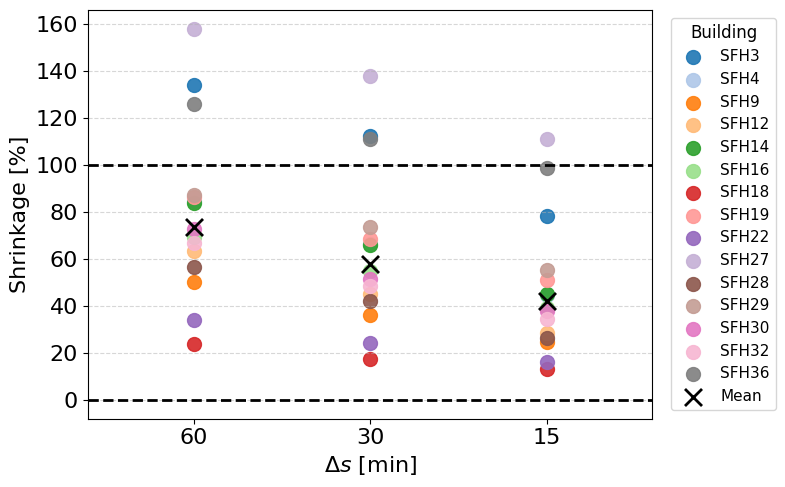

In [17]:
fig, tidy = (
    plot_shrinkage_by_experiment_matplotlib(
        comparison_df,
        experiments=(60, 30, 15),
        summary_stat="mean",
    )
)

plt.show()

In [19]:
import html
import pandas as pd

from IPython.display import HTML, display


# Columns shown in the final tables
TABLE_COLUMNS = [
    ("model_label", "Model"),
    ("e_import_total", "Imp.<br>[kWh]"),
    ("import_cost", "Costs Imp.<br>[€]"),
    ("e_export_total", "Exp.<br>[kWh]"),
    ("export_revenue", "Costs Exp.<br>[€]"),
    ("e_discharged_total", "E Dis.<br>[kWh]"),
    ("e_battery_deg_costs", "Degrad.<br>[€]"),
    ("net_cost_adj", "Bill<br>[€]"),
    ("net_cost_final", "Total Costs<br>[€]"),
    ("relative_performance", "Rel. Perf.<br>[%]"),
    ("avg_rank", "Mean Rank<br>[-]"),
]


def prepare_leaderboard_section(
    mre,
    model_order,
    model_labels,
):
    """
    Prepare one 60/30/15-minute section from leaderboard_mean().
    """

    df = mre.leaderboard_mean(
        round_ndigits=None
    ).copy()

    # Keep only the requested models
    df = df[
        df["model"].isin(model_order)
    ].copy()

    # Set the required row order
    df["model"] = pd.Categorical(
        df["model"],
        categories=model_order,
        ordered=True,
    )

    df = (
        df.sort_values("model")
        .reset_index(drop=True)
    )

    # Display names used in the table
    df["model_label"] = (
        df["model"]
        .astype("object")
        .map(model_labels)
    )

    # Relative performance compared with RBC
    rb_rows = df[
        df["model"].astype("object")
        == "rule-based"
    ]

    if rb_rows.empty:
        raise ValueError(
            "The rule-based model was not found."
        )

    rb_total_cost = rb_rows[
        "net_cost_final"
    ].iloc[0]

    df["relative_performance"] = (
        (
            df["net_cost_final"]
            - rb_total_cost
        )
        / abs(rb_total_cost)
        * 100
    )

    # Show a dash for RBC
    rb_mask = (
        df["model"].astype("object")
        == "rule-based"
    )

    df.loc[
        rb_mask,
        "relative_performance"
    ] = float("nan")

    return df


def format_table_value(
    value,
    column,
):
    """Format values like the paper table."""

    if pd.isna(value):
        return "-"

    if column == "model_label":
        return html.escape(str(value))

    return f"{float(value):.2f}"


def create_publication_table(
    sections,
    title,
    ground_truth_labels,
):
    """
    Create one publication-style HTML table containing
    the 60, 30 and 15-minute sections.
    """

    header_html = "".join(
        f"<th>{label}</th>"
        for _, label in TABLE_COLUMNS
    )

    body_rows = []

    for frequency, dataframe in sections:
        gt_label = ground_truth_labels[
            frequency
        ]

        # Section header spanning all columns
        body_rows.append(
            f"""
            <tr class="section-row">
                <td colspan="{len(TABLE_COLUMNS)}">
                    Schedule Step
                    Δs = {frequency}min
                    <span class="separator">———</span>
                    Ground-Truth Resolution
                    Δgt = {gt_label}
                </td>
            </tr>
            """
        )

        for _, row in dataframe.iterrows():
            cells = []

            for column, _ in TABLE_COLUMNS:
                value = row[column]

                cells.append(
                    "<td>"
                    + format_table_value(
                        value,
                        column,
                    )
                    + "</td>"
                )

            body_rows.append(
                "<tr>"
                + "".join(cells)
                + "</tr>"
            )

    return f"""
    <div class="publication-table-container">

        <div class="publication-table-title">
            {title}
        </div>

        <table class="publication-table">
            <thead>
                <tr>
                    {header_html}
                </tr>
            </thead>

            <tbody>
                {''.join(body_rows)}
            </tbody>
        </table>

    </div>
    """


# ==========================================================
# TABLE II: Fully Averaged Evaluation
# ==========================================================

fully_averaged_model_order = [
    "ideal",
    "rule-based",
    "mpc_det_rule_constGrid",
]

fully_averaged_model_labels = {
    "ideal": "MPC (Ideal)",
    "rule-based": "RBC",
    "mpc_det_rule_constGrid":
        "MPC (Real) Const-Grid",
}


table_ii_sections = [
    (
        60,
        prepare_leaderboard_section(
            mre_f60_gt60,
            fully_averaged_model_order,
            fully_averaged_model_labels,
        ),
    ),
    (
        30,
        prepare_leaderboard_section(
            mre_f30_gt30,
            fully_averaged_model_order,
            fully_averaged_model_labels,
        ),
    ),
    (
        15,
        prepare_leaderboard_section(
            mre_f15_gt15,
            fully_averaged_model_order,
            fully_averaged_model_labels,
        ),
    ),
]


table_ii_html = create_publication_table(
    sections=table_ii_sections,
    title=(
        "TABLE II: Fully Averaged Evaluation: "
        "Δs = Δgt"
    ),
    ground_truth_labels={
        60: "60min",
        30: "30min",
        15: "15min",
    },
)


# ==========================================================
# TABLE III: Fine-Resolution Evaluation with GT = 10 seconds
# ==========================================================

fine_resolution_model_order = [
    "ideal_rule_constGrid",
    "rule-based",
    "mpc_det_rule_constGrid",
    "ideal",
]

fine_resolution_model_labels = {
    "ideal_rule_constGrid":
        "MPC (Ideal) Const-Grid",
    "rule-based":
        "RBC",
    "mpc_det_rule_constGrid":
        "MPC (Real) Const-Grid",
    "ideal":
        "MPC (Ideal)",
}


table_iii_sections = [
    (
        60,
        prepare_leaderboard_section(
            mre_f60_gt10s,
            fine_resolution_model_order,
            fine_resolution_model_labels,
        ),
    ),
    (
        30,
        prepare_leaderboard_section(
            mre_f30_gt10s,
            fine_resolution_model_order,
            fine_resolution_model_labels,
        ),
    ),
    (
        15,
        prepare_leaderboard_section(
            mre_f15_gt10s,
            fine_resolution_model_order,
            fine_resolution_model_labels,
        ),
    ),
]


table_iii_html = create_publication_table(
    sections=table_iii_sections,
    title=(
        "TABLE III: Fine-Resolution Evaluation: "
        "Δs ≠ Δgt = 10s"
    ),
    ground_truth_labels={
        60: "10s",
        30: "10s",
        15: "10s",
    },
)


# ==========================================================
# Styling and display
# ==========================================================

table_css = """
<style>
.publication-table-container {
    width: 100%;
    margin: 25px auto 45px auto;
    font-family: "Times New Roman", serif;
}

.publication-table-title {
    text-align: center;
    font-size: 19px;
    font-weight: bold;
    margin-bottom: 8px;
}

.publication-table {
    width: 100%;
    border-collapse: collapse;
    font-size: 14px;
}

.publication-table thead {
    border-top: 2px solid black;
    border-bottom: 3px double black;
}

.publication-table th {
    padding: 6px 8px;
    text-align: center;
    font-weight: bold;
    line-height: 1.1;
}

.publication-table th:first-child {
    text-align: left;
}

.publication-table td {
    padding: 4px 8px;
    text-align: right;
    white-space: nowrap;
}

.publication-table td:first-child {
    text-align: left;
}

.publication-table .section-row {
    border-top: 3px double black;
    border-bottom: 1px solid black;
}

.publication-table .section-row td {
    padding: 7px;
    text-align: center;
    font-weight: bold;
}

.publication-table tbody tr:last-child {
    border-bottom: 2px solid black;
}

.publication-table .separator {
    display: inline-block;
    margin: 0 12px;
}
</style>
"""


complete_html = (
    table_css
    + table_ii_html
    + table_iii_html
)

display(HTML(complete_html))

## 1 - Load Optimization Results and calculate costs

### Scheduler-Step Length: 60 min

## 2 - Calculate Metrics

In [20]:
# Load all needed data into one big dataframe
cols_in_paper = ['model', 'e_import_total', 'import_cost', 'e_export_total', 'export_revenue', 'e_discharged_total', 'e_battery_deg_costs', 'net_cost_adj', 'net_cost_final']

# Get the rows for 'ideal' model as Series
ideal_60_gt60 = mref60_gt60_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_60_gt1 = mref60_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_30_gt30 = mref30_gt30_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_30_gt1 = mref30_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_15_gt15 = mref15_gt15_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_15_gt1 = mref15_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']

rb_60_gt60 = mref60_gt60_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['rule-based']
rb_60_gt1 = mref60_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['rule-based']
rb_30_gt30 = mref30_gt30_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['rule-based']
rb_30_gt1 = mref30_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['rule-based']
rb_15_gt15 = mref15_gt15_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['rule-based']
rb_15_gt1 = mref15_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['rule-based']

real_60_gt60 = mref60_gt60_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['mpc_det_rule_constGrid']
real_60_gt1 = mref60_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['mpc_det_rule_constGrid']
real_30_gt30 = mref30_gt30_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['mpc_det_rule_constGrid']
real_30_gt1 = mref30_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['mpc_det_rule_constGrid']
real_15_gt15 = mref15_gt15_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['mpc_det_rule_constGrid']
real_15_gt1 = mref15_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['mpc_det_rule_constGrid']

ideal_GRID_60_gt60 = mref60_gt60_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_GRID_60_gt1 = mref60_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal_rule_constGrid']
ideal_GRID_30_gt30 = mref30_gt30_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_GRID_30_gt1 = mref30_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal_rule_constGrid']
ideal_GRID_15_gt15 = mref15_gt15_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal']
ideal_GRID_15_gt1 = mref15_gt1_c8.leaderboard_mean()[cols_in_paper].set_index('model').loc['ideal_rule_constGrid']


# Combine into a DataFrame
df_big_mean = pd.DataFrame({
    'ideal_f60-gt60-c8': ideal_60_gt60,
    'ideal_f60-gt1-c8': ideal_60_gt1, 
    'ideal_f30-gt30-c8': ideal_30_gt30,
    'ideal_f30-gt1-c8': ideal_30_gt1,
    'ideal_f15-gt15-c8': ideal_15_gt15,
    'ideal_f15-gt1-c8': ideal_15_gt1, 
    'rb_f60-gt60-c8': rb_60_gt60,
    'rb_f60-gt1-c8': rb_60_gt1,
    'rb_f30-gt30-c8': rb_30_gt30,
    'rb_f30-gt1-c8': rb_30_gt1,
    'rb_f15-gt15-c8': rb_15_gt15,
    'rb_f15-gt1-c8': rb_15_gt1,
    'real_f60-gt60-c8': real_60_gt60,
    'real_f60-gt1-c8': real_60_gt1,
    'real_f30-gt30-c8': real_30_gt30,
    'real_f30-gt1-c8': real_30_gt1,
    'real_f15-gt15-c8': real_15_gt15,
    'real_f15-gt1-c8': real_15_gt1,
    'idealGRID_f60-gt60-c8': ideal_GRID_60_gt60,
    'idealGRID_f60-gt1-c8': ideal_GRID_60_gt1,
    'idealGRID_f30-gt30-c8': ideal_GRID_30_gt30,
    'idealGRID_f30-gt1-c8': ideal_GRID_30_gt1,
    'idealGRID_f15-gt15-c8': ideal_GRID_15_gt15,
    'idealGRID_f15-gt1-c8': ideal_GRID_15_gt1
}).T

df_big_mean

# Now compute relative improvements of net_cost_final when compared to rule-based
# go through each row and compute the relative improvement based on the rule-based value on another row with the same suffix
def compute_relative_improvement(row, reference_df):
    model_name = row.name
    if 'rb_' in model_name:
        return np.nan  # No improvement over itself
    suffix = model_name.split('_', 1)[1]  # Get the part after the first underscore
    rb_model_name = f'rb_{suffix}'
    if rb_model_name in reference_df.index:
        rb_value = reference_df.at[rb_model_name, 'net_cost_final']
        if rb_value == 0:
            return np.nan  # Avoid division by zero
        return round((rb_value - row['net_cost_final']) / abs(rb_value) * 100, 2)  # Relative improvement in percentage
    else:
        print("Hi")
        return np.nan  # Reference model not found

rel_impr = df_big_mean.apply(lambda row: compute_relative_improvement(row, df_big_mean), axis=1)
rel_impr.name = 'rel_imp_net_cost_final_vs_rb'
rel_impr

NameError: name 'mref60_gt60_c8' is not defined

### Latex Tables & Ranking

In [ ]:
cols_in_paper = ['model', 'e_import_total', 'import_cost', 'e_export_total', 'export_revenue', 'e_discharged_total', 'e_battery_deg_costs', 'net_cost_adj', 'net_cost_final', 'avg_rank']

def get_latex_table(mre, caption, filename):
    latex_table = mre.leaderboard_mean()[cols_in_paper].to_latex(index=False,float_format="%.2f", caption=caption)
    with open(f"tables/{filename}_fixedEval.txt", "w") as f:
        f.write(latex_table)

#get_latex_table(mref60_gt60_c8, "f60-gt60-c8", "latex_table_f60-gt60-c8")
#get_latex_table(mref60_gt1_c8, "f60-gt1-c8", "latex_table_f60-gt1-c8")
#get_latex_table(mref30_gt30_c8, "f30-gt30-c8", "latex_table_f30-gt30-c8")
#get_latex_table(mref30_gt1_c8, "f30-gt1-c8", "latex_table_f30-gt1-c8")
#get_latex_table(mref15_gt15_c8, "f15-gt15-c8", "latex_table_f15-gt15-c8")
#get_latex_table(mref15_gt1_c8, "f15-gt1-c8", "latex_table_f15-gt1-c8")

In [ ]:
def get_ranking(mre, models, value="net_cost_final"):
    pvt = mre.pivot(models=models, value=value)
    
    ranks = pvt.rank(axis=1, ascending=True, method='min').astype(int).add_suffix('_rank')
    return pd.concat([pvt, ranks], axis=1)

rank_f60_gt60_c8 = get_ranking(mref60_gt60_c8, models=["ideal", "rule-based", "mpc_det_rule_constGrid"])
rank_f30_gt30_c8 = get_ranking(mref30_gt30_c8, models=["ideal", "rule-based", "mpc_det_rule_constGrid"])
rank_f15_gt15_c8 = get_ranking(mref15_gt15_c8, models=["ideal", "rule-based", "mpc_det_rule_constGrid"])

print("Ranking f60-gt60-c8 Mean Ranks: ", rank_f60_gt60_c8[['ideal_rank', 'rule-based_rank', 'mpc_det_rule_constGrid_rank']].mean().to_dict())
print("Ranking f30-gt30-c8 Mean Ranks: ", rank_f30_gt30_c8[['ideal_rank', 'rule-based_rank', 'mpc_det_rule_constGrid_rank']].mean().to_dict())
print("Ranking f15-gt15-c8 Mean Ranks: ", rank_f15_gt15_c8[['ideal_rank', 'rule-based_rank', 'mpc_det_rule_constGrid_rank']].mean().to_dict())

print("\n\n")

rank_f60_gt1_c8 = get_ranking(mref60_gt1_c8, models=["ideal", "ideal_rule_constGrid", "rule-based", "mpc_det_rule_constGrid"])
rank_f30_gt1_c8 = get_ranking(mref30_gt1_c8, models=["ideal", "ideal_rule_constGrid", "rule-based", "mpc_det_rule_constGrid"])
rank_f15_gt1_c8 = get_ranking(mref15_gt1_c8, models=["ideal", "ideal_rule_constGrid", "rule-based", "mpc_det_rule_constGrid"])

print("Ranking f60-gt1-c8 Mean Ranks: ", rank_f60_gt1_c8[['ideal_rank', 'ideal_rule_constGrid_rank', 'rule-based_rank', 'mpc_det_rule_constGrid_rank']].mean().to_dict())
print("Ranking f30-gt1-c8 Mean Ranks: ", rank_f30_gt1_c8[['ideal_rank', 'ideal_rule_constGrid_rank', 'rule-based_rank', 'mpc_det_rule_constGrid_rank']].mean().to_dict())
print("Ranking f15-gt1-c8 Mean Ranks: ", rank_f15_gt1_c8[['ideal_rank', 'ideal_rule_constGrid_rank', 'rule-based_rank', 'mpc_det_rule_constGrid_rank']].mean().to_dict())

Ranking f60-gt60-c8 Mean Ranks:  {('ideal_rank', '60_rank'): 1.0, ('rule-based_rank', '60_rank'): 2.2, ('mpc_det_rule_constGrid_rank', '60_rank'): 2.8}
Ranking f30-gt30-c8 Mean Ranks:  {('ideal_rank', '30_rank'): 1.0, ('rule-based_rank', '30_rank'): 2.2, ('mpc_det_rule_constGrid_rank', '30_rank'): 2.8}
Ranking f15-gt15-c8 Mean Ranks:  {('ideal_rank', '15_rank'): 1.0, ('rule-based_rank', '15_rank'): 2.1333333333333333, ('mpc_det_rule_constGrid_rank', '15_rank'): 2.8666666666666667}



Ranking f60-gt1-c8 Mean Ranks:  {('ideal_rank', '60_rank'): 4.0, ('ideal_rule_constGrid_rank', '60_rank'): 1.2, ('rule-based_rank', '60_rank'): 1.8, ('mpc_det_rule_constGrid_rank', '60_rank'): 3.0}
Ranking f30-gt1-c8 Mean Ranks:  {('ideal_rank', '30_rank'): 3.933333333333333, ('ideal_rule_constGrid_rank', '30_rank'): 1.1333333333333333, ('rule-based_rank', '30_rank'): 1.8666666666666667, ('mpc_det_rule_constGrid_rank', '30_rank'): 3.066666666666667}
Ranking f15-gt1-c8 Mean Ranks:  {('ideal_rank', '15_rank'

In [ ]:
def get_diff(mre, freq: int, models= ["rule-based", "ideal"], value: str = "net_cost_final") -> pd.DataFrame:
    df = mre.pivot(models=models, value=value)
    df['diff'] = df[(models[0], freq)] - df[(models[1], freq)]

    # Sort according to the index which is SFH number
    df = df.sort_index(key=lambda x: x.map(lambda y: int(re.search(r"SFH(\d+)", y).group(1))))

    return df
print("Comparison of Costs RB - to Ideal-ConstGrid\n")

diff_f60_gt60_c8 = get_diff(mref60_gt60_c8, freq=60)
diff_f60_gt1_c8  = get_diff(mref60_gt1_c8, freq=60, models=['rule-based', 'ideal_rule_constGrid'])
diff_f30_gt30_c8 = get_diff(mref30_gt30_c8, freq=30)
diff_f30_gt1_c8  = get_diff(mref30_gt1_c8, freq=30, models=['rule-based', 'ideal_rule_constGrid'])
diff_f15_gt15_c8 = get_diff(mref15_gt15_c8, freq=15)
diff_f15_gt1_c8  = get_diff(mref15_gt1_c8, freq=15, models=['rule-based', 'ideal_rule_constGrid'])

print("f60-gt60-c8: ", diff_f60_gt60_c8['diff'].mean())
print("f60-gt1-c8:  ", diff_f60_gt1_c8['diff'].mean())
print("f30-gt30-c8: ", diff_f30_gt30_c8['diff'].mean())
print("f30-gt1-c8:  ", diff_f30_gt1_c8['diff'].mean())
print("f15-gt15-c8: ", diff_f15_gt15_c8['diff'].mean())
print("f15-gt1-c8:  ", diff_f15_gt1_c8['diff'].mean())


Comparison of Costs RB - to Ideal-ConstGrid

f60-gt60-c8:  30.461119297704283
f60-gt1-c8:   9.456103234393078
f30-gt30-c8:  30.44098038794771
f30-gt1-c8:   14.25259529695859
f15-gt15-c8:  30.44703578983789
f15-gt1-c8:   19.159098025864033


In [ ]:
from pathlib import Path
import re

#f60gt10s

time_of_executions = [
    "2026-07-24_12-42", 
    "2026-07-26_15-36", 
    "2026-07-24_12-56"  
]

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]

csvs = [p for p in csvs if "SFH10" not in p.name]

csvs = sorted(csvs, key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))

mref60_gt60_c8 = MultiRunEvaluator(run_paths=csvs)
mref60_gt60_c8.leaderboard_mean()


,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,60.0,1208.72,257.21,1154.11,124.29,2707.49,1350.43,113.44,9.97,132.92,130.96,244.40,1.2
1,rule-based,15,15,60.0,1140.19,324.09,1125.95,121.56,1187.14,595.34,50.01,0.31,202.53,202.47,252.48,1.8
2,mpc_det_rule_constGrid,15,15,60.0,1305.19,300.03,1252.28,136.53,2718.81,1357.06,113.99,8.05,163.50,161.92,275.92,3.0
3,ideal,15,15,60.0,1823.67,457.06,1779.10,198.82,2209.06,1101.24,92.50,10.00,258.24,256.28,348.79,4.0


In [ ]:
from pathlib import Path
import re

#f60gt60min

time_of_executions = [
    "2026-07-13_16-45", 
    "2026-07-10_21-08", 
    "2026-07-10_21-15"  
]

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]

csvs = [p for p in csvs if "SFH10" not in p.name]

csvs = sorted(csvs, key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))

mref60_gt60_c8 = MultiRunEvaluator(run_paths=csvs)
mref60_gt60_c8.leaderboard()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,60.0,1191.02,250.71,1148.97,123.77,2085.54,1039.51,87.32,9.97,126.93,124.98,212.30,1.4
1,ideal_rule_constGrid,15,15,60.0,1191.03,250.71,1148.98,123.77,2085.76,1039.62,87.33,9.97,126.93,124.98,212.31,1.6
2,rule-based,15,15,60.0,1132.74,322.04,1122.48,120.93,989.77,496.66,41.72,0.32,201.11,201.05,242.77,3.2
3,mpc_det_rule_constGrid,15,15,60.0,1290.35,295.30,1249.16,136.27,2136.72,1066.06,89.55,8.08,159.03,157.44,246.99,3.8


Shrinkage F60, GT60 & GT10s

In [ ]:
# Build the new MultiRunEvaluator objects for the requested sets
from pathlib import Path
import re

# Timestamps for the requested execution sets
f60_gt60_timestamps = ["2026-07-13_16-45", "2026-07-10_21-08", "2026-07-10_21-15"]
f60_gt10s_timestamps = ["2026-07-24_12-42", "2026-07-26_15-36", "2026-07-24_12-56"]


# Collect CSV paths by timestamp and filter out SFH10
# Sort by SFH number to get a consistent building order
def sfh_sort_key(path: Path):
    match = re.search(r"SFH(\d+)", path.name)
    return int(match.group(1)) if match else 9999

def gather_paths(timestamps):
    paths = []
    for ts in timestamps:
        paths.extend(Path("../runs").rglob(f"logs_{ts}*.csv"))
    paths = [p for p in paths if "SFH10" not in p.name]
    return sorted(paths, key=sfh_sort_key)

paths_f60_gt60 = gather_paths(f60_gt60_timestamps)
paths_f60_gt10s = gather_paths(f60_gt10s_timestamps)

mre_f60_gt60 = MultiRunEvaluator(run_paths=paths_f60_gt60)
mre_f60_gt10s = MultiRunEvaluator(run_paths=paths_f60_gt10s)

mre_f60_gt60.leaderboard_mean()
mre_f60_gt10s.leaderboard_mean()

mre_f60_gt60.leaderboard()
mre_f60_gt10s.leaderboard()

print(f"Loaded {len(paths_f60_gt60)} CSVs for mre_f60_gt60 and {len(paths_f60_gt10s)} CSVs for mre_f60_gt10s")


In [ ]:
import re
import pandas as pd


def get_diff(mre, freq: int, models= ["rule-based", "ideal"], value: str = "net_cost_final") -> pd.DataFrame:
    df = mre.pivot(models=models, value=value)
    df['diff'] = df[(models[0], freq)] - df[(models[1], freq)]


    df = df.sort_index(key=lambda x: x.map(lambda y: int(re.search(r"SFH(\d+)", y).group(1))))

    return df


diff_f60_gt60 = get_diff(mre_f60_gt60, freq=60, models=['rule-based', 'ideal'])
diff_f60_gt10s = get_diff(mre_f60_gt10s, freq=60, models=['rule-based', 'ideal_rule_constGrid'])


shrinkage_60 = 1 - (diff_f60_gt10s['diff'].mean() / diff_f60_gt60['diff'].mean())


shrinkage_df_mean = pd.DataFrame({'shrinkage_60': [shrinkage_60]})
display(shrinkage_df_mean)

print("Mean Absolute Difference in 60min (Predicted Edge):", diff_f60_gt60['diff'].mean())
print("Mean Absolute Difference in 10sec (Actual Edge):", diff_f60_gt10s['diff'].mean())
print('--------------------')
print(diff_f60_gt60)
print('--------------------')
print(diff_f60_gt10s)

,shrinkage_60
0,0.734755


Mean Absolute Difference in 60min (Predicted Edge): 30.46991265676618
Mean Absolute Difference in 10sec (Actual Edge): 8.081979190154149
--------------------
model          ideal  rule-based       diff
freq              60          60           
building                                   
SFH3      137.166082  167.264753  30.098670
SFH4      190.889334  226.792464  35.903130
SFH9      471.192671  528.494507  57.301837
SFH12     224.217472  253.374666  29.157194
SFH14     104.607126  135.138932  30.531806
SFH16     201.321093  230.125595  28.804502
SFH18     277.165767  306.588820  29.423054
SFH19      75.591342  100.775398  25.184056
SFH22     426.982447  468.983694  42.001247
SFH27      46.581396   59.001938  12.420542
SFH28     359.124082  402.622616  43.498534
SFH29     104.912994  124.463159  19.550165
SFH30      90.230857  104.446898  14.216041
SFH32     157.093094  185.441125  28.348031
SFH36     317.368964  347.978846  30.609882
--------------------
model    ideal_rule_constGrid

Shrinkage F30, GT30 & GT10s

In [ ]:
# Build the new MultiRunEvaluator objects for the requested sets
from pathlib import Path
import re

# Timestamps for the requested execution sets
f30_gt30_timestamps = ["2026-07-10_22-41", "2026-07-10_22-43", "2026-07-10_22-45"]
f30_gt10s_timestamps = ["2026-07-03_03-13", "2026-07-03_03-17", "2026-07-03_03-18"]

# Collect CSV paths by timestamp and filter out SFH10
# Sort by SFH number to get a consistent building order
def sfh_sort_key(path: Path):
    match = re.search(r"SFH(\d+)", path.name)
    return int(match.group(1)) if match else 9999

def gather_paths(timestamps):
    paths = []
    for ts in timestamps:
        paths.extend(Path("../runs").rglob(f"logs_{ts}*.csv"))
    paths = [p for p in paths if "SFH10" not in p.name]
    return sorted(paths, key=sfh_sort_key)

paths_f30_gt30 = gather_paths(f30_gt30_timestamps)
paths_f30_gt10s = gather_paths(f30_gt10s_timestamps)

mre_f30_gt30 = MultiRunEvaluator(run_paths=paths_f30_gt30)
mre_f30_gt10s = MultiRunEvaluator(run_paths=paths_f30_gt10s)

print(f"Loaded {len(paths_f30_gt30)} CSVs for mre_f30_gt30 and {len(paths_f30_gt10s)} CSVs for mre_f30_gt10s")


NameError: name 'lea' is not defined

In [ ]:
import re
import pandas as pd


def get_diff(mre, freq: int, models= ["rule-based", "ideal"], value: str = "net_cost_final") -> pd.DataFrame:
    df = mre.pivot(models=models, value=value)
    df['diff'] = df[(models[0], freq)] - df[(models[1], freq)]


    df = df.sort_index(key=lambda x: x.map(lambda y: int(re.search(r"SFH(\d+)", y).group(1))))

    return df


diff_f30_gt30 = get_diff(mre_f30_gt30, freq=30, models=['rule-based', 'ideal'])
diff_f30_gt10s = get_diff(mre_f30_gt10s, freq=30, models=['rule-based', 'ideal_rule_constGrid'])


shrinkage_30 = 1 - (diff_f30_gt10s['diff'].mean() / diff_f30_gt30['diff'].mean())


shrinkage_df_mean = pd.DataFrame({'shrinkage_30': [shrinkage_30]})
display(shrinkage_df_mean)

print("Mean Absolute Difference in 30min (Predicted Edge):", diff_f30_gt30['diff'].mean())
print("Mean Absolute Difference in 10sec (Actual Edge):", diff_f30_gt10s['diff'].mean())

,shrinkage_30
0,0.579841


Mean Absolute Difference in 30min (Predicted Edge): 30.412552008002717
Mean Absolute Difference in 10sec (Actual Edge): 12.778092549911443


In [ ]:
from pathlib import Path
import re

time_of_executions = [
    "2026-07-03_02-25", 
    "2026-07-03_03-00", 
    "2026-07-17_19-26"  
]

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]

csvs = [p for p in csvs if "SFH10" not in p.name]

csvs = sorted(csvs, key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))

mref60_gt60_c8 = MultiRunEvaluator(run_paths=csvs)
mref60_gt60_c8.leaderboard_mean()

In [ ]:
from pathlib import Path
import re

time_of_executions = [
    "2026-07-10_22-48", 
    "2026-07-10_22-50", 
    "2026-07-10_22-51"  
]

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]

csvs = [p for p in csvs if "SFH10" not in p.name]

csvs = sorted(csvs, key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))

mref60_gt60_c8 = MultiRunEvaluator(run_paths=csvs)
mref60_gt60_c8.leaderboard_mean()

Shrinkage F15, GT15 & GT10s

In [ ]:
# Build the new MultiRunEvaluator objects for the requested sets
from pathlib import Path
import re

# Timestamps for the requested execution sets
f15_gt15_timestamps = ["2026-07-10_22-48", "2026-07-10_22-50", "2026-07-10_22-51"]
f15_gt10s_timestamps = ["2026-07-03_02-25", "2026-07-03_03-00", "2026-07-17_19-26"]

# Collect CSV paths by timestamp and filter out SFH10
# Sort by SFH number to get a consistent building order
def sfh_sort_key(path: Path):
    match = re.search(r"SFH(\d+)", path.name)
    return int(match.group(1)) if match else 9999

def gather_paths(timestamps):
    paths = []
    for ts in timestamps:
        paths.extend(Path("../runs").rglob(f"logs_{ts}*.csv"))
    paths = [p for p in paths if "SFH10" not in p.name]
    return sorted(paths, key=sfh_sort_key)

paths_f15_gt15 = gather_paths(f15_gt15_timestamps)
paths_f15_gt10s = gather_paths(f15_gt10s_timestamps)

mre_f15_gt15 = MultiRunEvaluator(run_paths=paths_f15_gt15)
mre_f15_gt10s = MultiRunEvaluator(run_paths=paths_f15_gt10s)

print(f"Loaded {len(paths_f15_gt15)} CSVs for mre_f15_gt15 and {len(paths_f15_gt10s)} CSVs for mre_f15_gt10s")


KeyboardInterrupt: 

In [ ]:
import re
import pandas as pd


def get_diff(mre, freq: int, models= ["rule-based", "ideal"], value: str = "net_cost_final") -> pd.DataFrame:
    df = mre.pivot(models=models, value=value)
    df['diff'] = df[(models[0], freq)] - df[(models[1], freq)]


    df = df.sort_index(key=lambda x: x.map(lambda y: int(re.search(r"SFH(\d+)", y).group(1))))

    return df



diff_f15_gt15 = get_diff(mre_f15_gt15, freq=15, models=['rule-based', 'ideal'])
diff_f15_gt10s = get_diff(mre_f15_gt10s, freq=15, models=['rule-based', 'ideal_rule_constGrid'])

print(diff_f15_gt15)

shrinkage_15 = 1 - (diff_f15_gt10s['diff'].mean() / diff_f15_gt15['diff'].mean())


shrinkage_df_mean = pd.DataFrame({'shrinkage_15': [shrinkage_15]})
display(shrinkage_df_mean)

print("Mean Absolute Difference in 15min (Predicted Edge):", diff_f15_gt15['diff'].mean())
print("Mean Absolute Difference in 10sec (Actual Edge):", diff_f15_gt10s['diff'].mean())

model          ideal  rule-based       diff
freq              15          15           
building                                   
SFH3      143.634636  172.951117  29.316482
SFH4      196.977530  232.476967  35.499437
SFH9      478.972032  535.948234  56.976202
SFH12     232.410589  261.752373  29.341784
SFH14     108.794196  139.492660  30.698464
SFH16     205.903845  234.188304  28.284459
SFH18     281.718002  311.350920  29.632918
SFH19      79.424723  104.926575  25.501852
SFH22     430.864642  472.925993  42.061351
SFH27      49.014416   61.567478  12.553062
SFH28     366.249473  409.844209  43.594736
SFH29     107.675425  127.046160  19.370735
SFH30      93.698923  108.077163  14.378240
SFH32     162.168732  190.405670  28.236938
SFH36     321.163029  351.664971  30.501942


,shrinkage_15
0,0.420387


Mean Absolute Difference in 15min (Predicted Edge): 30.396573312746458
Mean Absolute Difference in 10sec (Actual Edge): 17.61823719664308


In [ ]:


print('------------------------------')


print("Length of 15min (gt10s) diff:", len(diff_f15_gt10s))
print(diff_f15_gt10s)

------------------------------
Length of 15min (gt10s) diff: 15
model    ideal_rule_constGrid  rule-based       diff
freq                       15          15           
building                                            
SFH3               170.895180  177.269119   6.373939
SFH4               217.497026  237.115628  19.618602
SFH9               499.428339  542.225507  42.797168
SFH12              246.335707  267.277392  20.941685
SFH14              126.387336  143.248575  16.861238
SFH16              222.165566  239.311312  17.145746
SFH18              291.642084  317.295402  25.653319
SFH19               96.552700  109.052088  12.499388
SFH22              442.235404  477.414042  35.178638
SFH27               67.922062   66.524992  -1.397070
SFH28              383.693568  415.790621  32.097052
SFH29              120.692589  129.340565   8.647976
SFH30              102.962377  111.865686   8.903309
SFH32              176.309934  194.849248  18.539314
SFH36              358.248042  358.

In [ ]:
# get the differences between diff_f60_gt60_c8['diff'] and diff_f60_gt1_c8['diff']
full_values_df = pd.DataFrame({
    'ideal_f60-gt60-c8': diff_f60_gt60_c8['ideal'][60],
    'rb_f60-gt60-c8': diff_f60_gt60_c8['rule-based'][60],
    'ideal_f60-gt1-c8': diff_f60_gt1_c8['ideal_rule_constGrid'][60],
    'rb_f60-gt1-c8': diff_f60_gt1_c8['rule-based'][60],
    'ideal_f30-gt30-c8': diff_f30_gt30_c8['ideal'][30],
    'rb_f30-gt30-c8': diff_f30_gt30_c8['rule-based'][30],
    'ideal_f30-gt1-c8': diff_f30_gt1_c8['ideal_rule_constGrid'][30],
    'rb_f30-gt1-c8': diff_f30_gt1_c8['rule-based'][30],
    'ideal_f15-gt15-c8': diff_f15_gt15_c8['ideal'][15],
    'rb_f15-gt15-c8': diff_f15_gt15_c8['rule-based'][15],
    'ideal_f15-gt1-c8': diff_f15_gt1_c8['ideal_rule_constGrid'][15],
    'rb_f15-gt1-c8': diff_f15_gt1_c8['rule-based'][15],
    # 'real_f60-gt60-c8': diff_f60_gt60_c8['mpc_det_rule_constGrid'][60],
    # 'real_f60-gt1-c8': diff_f60_gt1_c8['mpc_det_rule_constGrid'][60],
    # 'real_f30-gt30-c8': diff_f30_gt30_c8['mpc_det_rule_constGrid'][30],
    # 'real_f30-gt1-c8': diff_f30_gt1_c8['mpc_det_rule_constGrid'][30],
    # 'real_f15-gt15-c8': diff_f15_gt15_c8['mpc_det_rule_constGrid'][15],
    # 'real_f15-gt1-c8': diff_f15_gt1_c8['mpc_det_rule_constGrid'][15]
    
})

comparison_df = pd.DataFrame({
    'diff_f60-gt60-c8': diff_f60_gt60_c8['diff'],
    'diff_f60-gt1-c8': diff_f60_gt1_c8['diff'],
    'diff_f30-gt30-c8': diff_f30_gt30_c8['diff'],
    'diff_f30-gt1-c8': diff_f30_gt1_c8['diff'],
    'diff_f15-gt15-c8': diff_f15_gt15_c8['diff'],
    'diff_f15-gt1-c8': diff_f15_gt1_c8['diff']
})

# Here, results are average of multiple buildings (in paper, focus was on the performance of an average building)

# OVERSTATEMENTS [€]
comparison_df['Overstatement_60'] = comparison_df['diff_f60-gt60-c8'] - comparison_df['diff_f60-gt1-c8']
comparison_df['Overstatement_30'] = comparison_df['diff_f30-gt30-c8'] - comparison_df['diff_f30-gt1-c8']
comparison_df['Overstatement_15'] = comparison_df['diff_f15-gt15-c8'] - comparison_df['diff_f15-gt1-c8']

# SHRINKAGE [-]
comparison_df['shrinkage_60'] = 1 -   comparison_df['diff_f60-gt1-c8'] / comparison_df['diff_f60-gt60-c8']  # Aka how much of the predicted benefit is lost. a=25% => 25% of the predicted benefit is lost. a>100 => Reversal of sign, more than 100% of predicted edge disappears (i.e. other evaluation would have picked wrong winner.)
comparison_df['shrinkage_30'] = 1 -   comparison_df['diff_f30-gt1-c8'] / comparison_df['diff_f30-gt30-c8']
comparison_df['shrinkage_15'] = 1 -   comparison_df['diff_f15-gt1-c8'] / comparison_df['diff_f15-gt15-c8']


# RELATIVE IMPROVEMENTS [-]
comparison_df['rel_gt60_improv_60'] = comparison_df['diff_f60-gt60-c8'] / full_values_df['rb_f60-gt60-c8']
comparison_df['rel_gt1_improv_60'] = comparison_df['diff_f60-gt1-c8'] / full_values_df['rb_f60-gt1-c8']
comparison_df['rel_gt30_improv_30'] = comparison_df['diff_f30-gt30-c8'] / full_values_df['rb_f30-gt30-c8']
comparison_df['rel_gt1_improv_30'] = comparison_df['diff_f30-gt1-c8'] / full_values_df['rb_f30-gt1-c8']
comparison_df['rel_gt15_improv_15'] = comparison_df['diff_f15-gt15-c8'] / full_values_df['rb_f15-gt15-c8']
comparison_df['rel_gt1_improv_15'] = comparison_df['diff_f15-gt1-c8'] / full_values_df['rb_f15-gt1-c8']

comparison_df['rel_improv_diff_60'] = comparison_df['rel_gt60_improv_60'] - comparison_df['rel_gt1_improv_60']
comparison_df['rel_improv_diff_30'] = comparison_df['rel_gt30_improv_30'] - comparison_df['rel_gt1_improv_30']
comparison_df['rel_improv_diff_15'] = comparison_df['rel_gt15_improv_15'] - comparison_df['rel_gt1_improv_15']


NameError: name 'diff_f60_gt60_c8' is not defined

In [ ]:
# Relative Improvement based on means
# mean of RBC - mean of method / mean of RBC
means = full_values_df.mean()
rel_imp_60_60 = (means['rb_f60-gt60-c8'] - means['ideal_f60-gt60-c8']) / means['rb_f60-gt60-c8']
rel_imp_30_30 = (means['rb_f30-gt30-c8'] - means['ideal_f30-gt30-c8']) / means['rb_f30-gt30-c8']
rel_imp_15_15 = (means['rb_f15-gt15-c8'] - means['ideal_f15-gt15-c8']) / means['rb_f15-gt15-c8']
rel_imp_60_1 = (means['rb_f60-gt1-c8'] - means['ideal_f60-gt1-c8']) / means['rb_f60-gt1-c8']
rel_imp_30_1 = (means['rb_f30-gt1-c8'] - means['ideal_f30-gt1-c8']) / means['rb_f30-gt1-c8']
rel_imp_15_1 = (means['rb_f15-gt1-c8'] - means['ideal_f15-gt1-c8']) / means['rb_f15-gt1-c8']

df_rel_imp_means = pd.DataFrame([{
    'rel_imp_60_60': rel_imp_60_60,
    'rel_imp_30_30': rel_imp_30_30,
    'rel_imp_15_15': rel_imp_15_15,
    'rel_imp_60_1': rel_imp_60_1,
    'rel_imp_30_1': rel_imp_30_1,
    'rel_imp_15_1': rel_imp_15_1
}])
df_rel_imp_means


,rel_imp_60_60,rel_imp_30_30,rel_imp_15_15,rel_imp_60_1,rel_imp_30_1,rel_imp_15_1
0,0.125475,0.124114,0.122948,0.037576,0.056637,0.076134


In [ ]:
comparison_df.mean()

diff_f60-gt60-c8      30.461119
diff_f60-gt1-c8        9.456103
diff_f30-gt30-c8      30.440980
diff_f30-gt1-c8       14.252595
diff_f15-gt15-c8      30.447036
diff_f15-gt1-c8       19.159098
Overstatement_60      21.005016
Overstatement_30      16.188385
Overstatement_15      11.287938
shrinkage_60           0.748757
shrinkage_30           0.584467
shrinkage_15           0.415833
rel_gt60_improv_60     0.146703
rel_gt1_improv_60      0.027670
rel_gt30_improv_30     0.144723
rel_gt1_improv_30      0.051556
rel_gt15_improv_15     0.142845
rel_gt1_improv_15      0.077224
rel_improv_diff_60     0.119033
rel_improv_diff_30     0.093167
rel_improv_diff_15     0.065622
dtype: float64

In [ ]:
full_values_df.mean()

ideal_f60-gt60-c8    212.305108
rb_f60-gt60-c8       242.766227
ideal_f60-gt1-c8     242.193892
rb_f60-gt1-c8        251.649996
ideal_f30-gt30-c8    214.825553
rb_f30-gt30-c8       245.266534
ideal_f30-gt1-c8     237.397400
rb_f30-gt1-c8        251.649996
ideal_f15-gt15-c8    217.194217
rb_f15-gt15-c8       247.641253
ideal_f15-gt1-c8     232.490898
rb_f15-gt1-c8        251.649996
dtype: float64

## 3 - Plots

In [ ]:
model_colors = {
    "ideal":                   "#9467bd",
    "ideal_rule":              "#8c564b",
    "mpc_det_rule":            "#2ca02c",
    "mpc_det_rule_constGrid":  "#17becf",
    "rule-based":              "#ff7f0e",
    "ideal_rule_constGrid":    "#1f77b4",
}

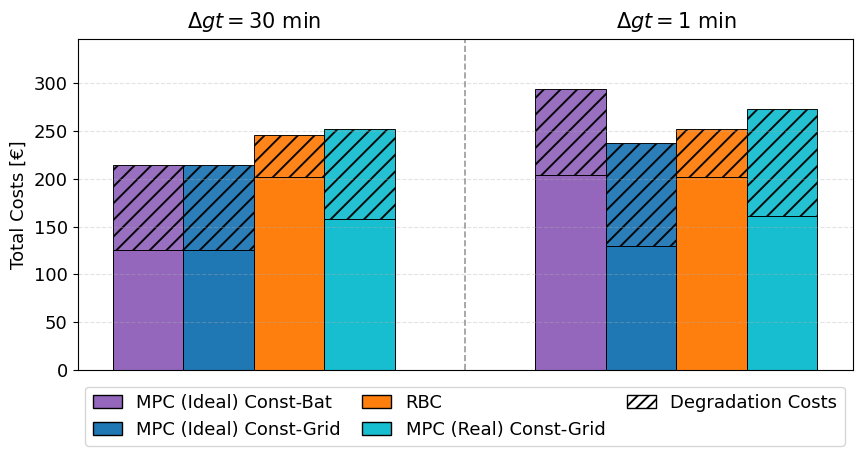

In [ ]:
def plot_split_stacked_costs(
    df_left: pd.DataFrame,
    df_right: pd.DataFrame,
    models_to_plot=("ideal", "rule-based", "mpc_det_rule"),
    bottom_col="net_cost_adj",       # Electricity costs
    top_col="e_battery_deg_costs",   # Degradation costs
    left_title="Dataset A",
    right_title="Dataset B",
    figsize=(10, 4.8),
    block_gap=1.0,                   # gap between LEFT and RIGHT blocks only
):
    # Use model as index
    L = df_left.set_index("model")
    R = df_right.set_index("model")

    # If ideal_rule_constGrid is missing, clone from ideal (for BOTH frames if possible)
    if "ideal_rule_constGrid" in models_to_plot:
        if ("ideal_rule_constGrid" not in L.index) and ("ideal" in L.index):
            L.loc["ideal_rule_constGrid"] = L.loc["ideal"]
        if ("ideal_rule_constGrid" not in R.index) and ("ideal" in R.index):
            R.loc["ideal_rule_constGrid"] = R.loc["ideal"]

    # Ensure all models exist in both frames
    missing = [m for m in models_to_plot if m not in L.index or m not in R.index]
    if missing:
        raise ValueError(f"Model(s) missing in one of the dataframes: {missing}")


    plt.rcParams.update({
        "axes.labelsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "hatch.linewidth": 1.4,
    })

    fig, ax = plt.subplots(figsize=figsize)

    n = len(models_to_plot)
    # --- Layout: narrower bars that still TOUCH within each side ---
    width = 0.5                          # bar width
    step  = width                        # center-to-center spacing so bars touch
    x_left  = np.arange(n) * step
    x_right = n * step + block_gap + np.arange(n) * step

    # tight x-limits (no side padding)
    ax.set_xlim(-width/2, x_right[-1] + width/2)
    ax.margins(x=0)

    ymax = 0.0
    # LEFT block
    for i, m in enumerate(models_to_plot):
        c = model_colors.get(m, "#777777")
        btm = float(L.loc[m, bottom_col])
        top = float(L.loc[m, top_col])

        ax.bar(x_left[i], btm, width, color=c, edgecolor="black", linewidth=0.7)
        ax.bar(x_left[i], top,  width, bottom=btm, color=c,
               edgecolor="black", linewidth=0.7, hatch="//", alpha=0.95)
        ymax = max(ymax, btm + top)

    # RIGHT block
    for i, m in enumerate(models_to_plot):
        c = model_colors.get(m, "#777777")
        btm = float(R.loc[m, bottom_col])
        top = float(R.loc[m, top_col])

        ax.bar(x_right[i], btm, width, color=c, edgecolor="black", linewidth=0.7)
        ax.bar(x_right[i], top,  width, bottom=btm, color=c,
               edgecolor="black", linewidth=0.7, hatch="//", alpha=0.95)
        ymax = max(ymax, btm + top)

    # # Separator line between blocks
    # sep_x = n - 0.5 + block_gap / 2
    # # fix separator line position to account for bar width
    # sep_x += width / 2

    # separator exactly between the two blocks in data coords
    sep_x = n * step + block_gap / 4
    ax.axvline(sep_x, color="gray", linestyle="--", linewidth=1.2, alpha=0.8)

    # X ticks & labels
    xticks = np.concatenate([x_left, x_right])
    xticklabels = list(models_to_plot) + list(models_to_plot)
    #ax.set_xticks(xticks)
    # set no x ticks
    ax.set_xticks([])

    #ax.set_xticklabels(xticklabels, rotation=0)

    # Tight x-limits so bars have no side padding
    ax.set_xlim(-0.5, x_right[-1] + 0.5)         # CHANGED
    ax.margins(x=0)                               # CHANGED

    # Axis label & grid
    ax.set_ylabel("Total Costs [€]")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_ylim(top=ymax + 0.18 * ymax)
    
   # Legend items
    # Change the name of the models in the legend
    model_legend = {
        "ideal":                   "MPC (Ideal) Const-Bat",
        "mpc_det_rule_constGrid":  "MPC (Real) Const-Grid",
        "rule-based":              "RBC",
        "ideal_rule_constGrid":    "MPC (Ideal) Const-Grid",
    }
    model_patches = [Patch(facecolor=model_colors.get(m, "#777777"),
                           edgecolor="black", label=model_legend.get(m, m)) for m in models_to_plot]
    #comp_elec = None#Patch(facecolor="white", edgecolor="black", label="Electricity Costs")
    comp_deg  = Patch(facecolor="white", edgecolor="black", hatch="///", label="Degradation Costs")
    #handles = model_patches + [comp_elec, comp_deg]
    handles = model_patches + [comp_deg]

    # ---- Legend below, centered in two rows ----
    ncols = math.ceil(len(handles) / 2)
    ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),  # push below axes
        ncol=ncols,
        frameon=True,
        borderaxespad=0.0,
        handlelength=1.6,
        columnspacing=1.2
    )

    # --- Put the left/right titles OUTSIDE the plot area, like a figure title ---
    # Reserve more top margin for the headers:
    fig.subplots_adjust(top=0.8)                 # CHANGED

    # Compute centers in figure fraction and place texts high, like titles
    fig_bb = ax.get_position()
    xmin, xmax = ax.get_xlim()
    to_ax = lambda x: (x - xmin) / (xmax - xmin)

    left_center_fig_x  = fig_bb.x0 + to_ax(x_left.mean())  * fig_bb.width
    right_center_fig_x = fig_bb.x0 + to_ax(x_right.mean()) * fig_bb.width

    title_y = 0.81                                 # CHANGED: “title-like” height
    fig.text(left_center_fig_x,  title_y, left_title,
             ha="center", va="bottom", fontsize=15, fontweight="bold")
    fig.text(right_center_fig_x, title_y, right_title,
             ha="center", va="bottom", fontsize=15, fontweight="bold")

    return fig, ax


fig, ax = plot_split_stacked_costs(
    mref30_gt30_c8.leaderboard_mean(), mref30_gt1_c8.leaderboard_mean(),
    models_to_plot = ("ideal", "ideal_rule_constGrid", "rule-based", "mpc_det_rule_constGrid"),
    left_title=r"$\Delta gt = 30 \ \text{min}$",
    right_title=r"$\Delta gt = 1 \ \text{min}$",
    block_gap=1.0,
)
#fig.savefig("costs_f30_split_v2.pdf", bbox_inches="tight")
plt.show()

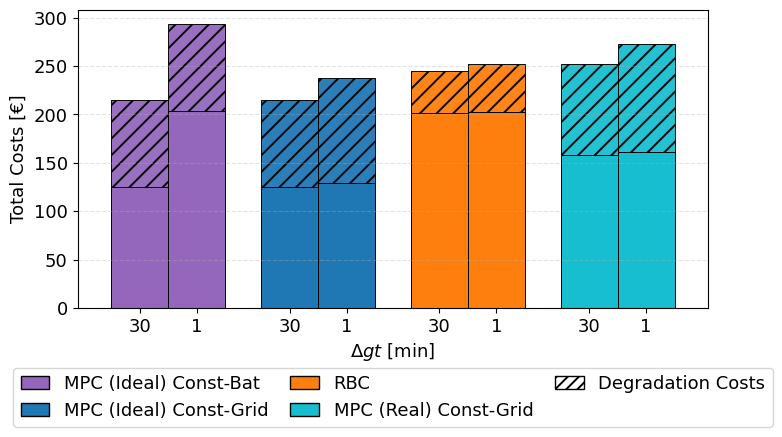

In [ ]:
def plot_two_df_stacked_costs(
    df_left: pd.DataFrame,
    df_right: pd.DataFrame,
    models_to_plot=("ideal", "rule-based", "mpc_det_rule"),
    bottom_col="net_cost_adj",
    top_col="e_battery_deg_costs",
    figsize=(8, 6), # 10, 4.5 for right side legend
):
    # Use model as index
    L = df_left.set_index("model").copy()
    R = df_right.set_index("model").copy()

    # If ideal_rule_constGrid is missing, clone from ideal (for BOTH frames if possible)
    if "ideal_rule_constGrid" in models_to_plot:
        if ("ideal_rule_constGrid" not in L.index) and ("ideal" in L.index):
            L.loc["ideal_rule_constGrid"] = L.loc["ideal"]
        if ("ideal_rule_constGrid" not in R.index) and ("ideal" in R.index):
            R.loc["ideal_rule_constGrid"] = R.loc["ideal"]

    # Ensure all models exist in both frames
    missing = [m for m in models_to_plot if m not in L.index or m not in R.index]
    if missing:
        raise ValueError(f"Model(s) missing in one of the dataframes: {missing}")

    # Styling
    plt.rcParams.update({
        "axes.labelsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "hatch.linewidth": 1.4,
    })

    n = len(models_to_plot)
    x = np.arange(n, dtype=float)
    width = 0.38
    pos_left  = x - width/2
    pos_right = x + width/2

    fig, ax = plt.subplots(figsize=figsize)

    # Bars
    for i, m in enumerate(models_to_plot):
        c = model_colors.get(m, "#777777")

        btm_L = float(L.loc[m, bottom_col]); top_L = float(L.loc[m, top_col])
        ax.bar(pos_left[i],  btm_L, width, color=c, edgecolor="black", linewidth=0.7)
        ax.bar(pos_left[i],  top_L, width, bottom=btm_L, color=c,
               edgecolor="black", linewidth=0.7, hatch="//", alpha=0.95)

        btm_R = float(R.loc[m, bottom_col]); top_R = float(R.loc[m, top_col])
        ax.bar(pos_right[i], btm_R, width, color=c, edgecolor="black", linewidth=0.7)
        ax.bar(pos_right[i], top_R, width, bottom=btm_R, color=c,
               edgecolor="black", linewidth=0.7, hatch="//", alpha=0.95)

    # One tick per bar: l/r
    ticks   = [p for pair in zip(pos_left, pos_right) for p in pair]
    labels  = [lab for _ in range(n) for lab in ("30", "1")]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

    ax.set_ylabel("Total Costs [€]")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.margins(x=0.06)

    # Legend outside right: model colors + hatched degradation item
    # Change the name of the models in the legend
    model_legend = {
        "ideal":                   "MPC (Ideal) Const-Bat",
        "mpc_det_rule_constGrid":  "MPC (Real) Const-Grid",
        "rule-based":              "RBC",
        "ideal_rule_constGrid":    "MPC (Ideal) Const-Grid",
    }

    model_patches = [Patch(facecolor=model_colors.get(m, "#777777"),
                           edgecolor="black", label=model_legend.get(m, m)) for m in models_to_plot]
    deg_patch = Patch(facecolor="white", edgecolor="black", hatch="///",
                      label="Degradation Costs")


    # ---- Legend below, centered in two rows ----
    handles = model_patches + [deg_patch]

    # two rows ⇒ columns = ceil(len(handles)/2)
    import math
    ncols = math.ceil(len(handles) / 2)

    leg = ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),   # push below the axes
        ncol=ncols,
        frameon=True,
        borderaxespad=0.0,
        handlelength=1.6,
        columnspacing=1.2
    )
    leg.get_title().set_multialignment('center')
    # Make room at the bottom for the legend (no right padding needed anymore)
    plt.tight_layout(rect=[0, 0.2, 1, 1])

    ax.set_xlabel(r"$\Delta gt$ [min]")
    return fig, ax
models = ("ideal", "ideal_rule_constGrid", "rule-based", "mpc_det_rule_constGrid")

fig, ax = plot_two_df_stacked_costs(mref30_gt30_c8.leaderboard_mean(), mref30_gt1_c8.leaderboard_mean(), models_to_plot=models)
#fig.savefig("costs_f30_v2.pdf", bbox_inches="tight")
plt.show()

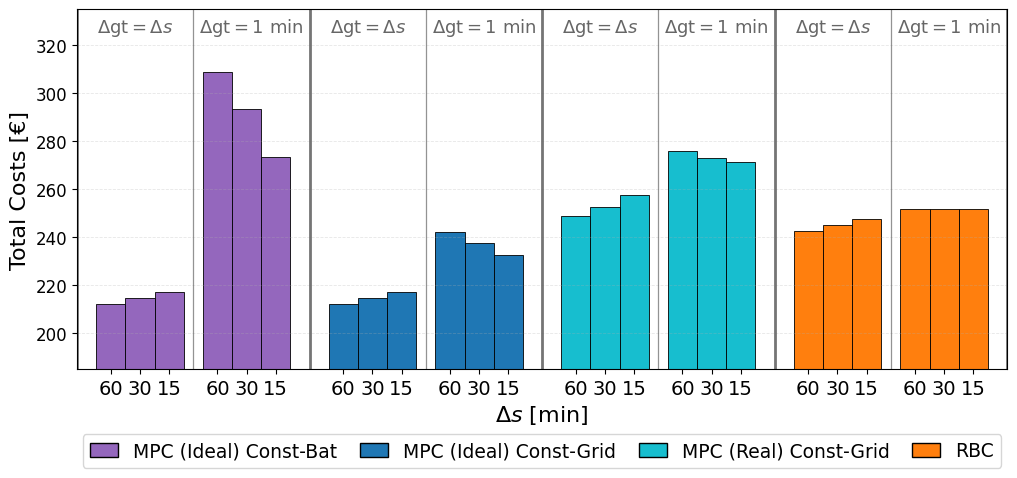

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_two_groups_per_model_total_costs(
    df_60_60: pd.DataFrame,
    df_60_1: pd.DataFrame,
    df_30_30: pd.DataFrame,
    df_30_1: pd.DataFrame,
    df_15_15: pd.DataFrame,
    df_15_1: pd.DataFrame,
    models_to_plot=("ideal", "rule-based", "mpc_det_rule_constGrid"),
    bottom_col="net_cost_adj",
    top_col="e_battery_deg_costs",
    figsize=(12, 6),
    subgap=0.35,
    model_gap=0.9,
    bar_width=0.26,
    # headers & separators
    f30_header_frac_y=0.92,  # height as FRACTION of y-axis (0..1)
    f30_header_color="#666666",
    f30_left_text=r"$\Delta \mathrm{gt}=\Delta s$",
    f30_right_text=r"$\Delta \mathrm{gt}=1\ \mathrm{min}$",
    inner_sep_color="#666666",
    inner_sep_lw=0.9,
    block_sep_lw=2.0,
):
    # Build lookup dicts
    D = {
        ("60","left"): df_60_60.set_index("model"),
        ("60","right"): df_60_1.set_index("model"),
        ("30","left"): df_30_30.set_index("model"),
        ("30","right"): df_30_1.set_index("model"),
        ("15","left"): df_15_15.set_index("model"),
        ("15","right"): df_15_1.set_index("model"),
    }

    # clone ideal -> ideal_rule_constGrid if requested but missing
    for f in ("60","30","15"):
        for side in ("left","right"):
            df = D[(f,side)]
            if "ideal_rule_constGrid" in models_to_plot:
                if ("ideal_rule_constGrid" not in df.index) and ("ideal" in df.index):
                    df.loc["ideal_rule_constGrid"] = df.loc["ideal"]

    # presence check
    missing = [m for m in models_to_plot
               if any(m not in D[(f,side)].index for f in ("60","30","15") for side in ("left","right"))]
    if missing:
        raise ValueError(f"Model(s) missing in one or more dataframes: {missing}")

    model_colors = {
        "ideal":                   "#9467bd",
        "ideal_rule":              "#8c564b",
        "mpc_det_rule":            "#2ca02c",
        "mpc_det_rule_constGrid":  "#17becf",
        "rule-based":              "#ff7f0e",
        "ideal_rule_constGrid":    "#1f77b4",
    }

    plt.rcParams.update({
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 12,
        "legend.fontsize": 13.5,
        "hatch.linewidth": 1.4,
    })

    fig, ax = plt.subplots(figsize=figsize)

    order = ("60","30","15")

    # layout (bars touch within groups)
    step = bar_width
    group_span = 3 * step
    block_span = group_span + subgap + group_span
    x0 = 0.0

    # positions: list of (x, model, freq, side)
    x_positions = []
    for model in models_to_plot:
        # left mini-group
        for j, f in enumerate(order):
            x_positions.append((x0 + j*step, model, f, "left"))
        # right mini-group
        right_start = x0 + group_span + subgap
        for j, f in enumerate(order):
            x_positions.append((right_start + j*step, model, f, "right"))
        x0 += block_span + model_gap

    # draw bars
    for x, model, f, side in x_positions:
        c = model_colors.get(model, "#777")
        df = D[(f, side)]
        total = float(df.loc[model, bottom_col]) + float(df.loc[model, top_col])
        ax.bar(x, total, bar_width, color=c, edgecolor="black", linewidth=0.6)

    # axes cosmetics (initial)
    ax.set_ylabel("Total Costs [€]")
    ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.6)
    ax.set_xticks([xp[0] for xp in x_positions])
    ax.set_xticklabels([xp[2] for xp in x_positions])  # "60/30/15"
    ax.set_ylim(185, 335)

    # ---------- per-model x lists (sorted) ----------
    by_model = {m: sorted([x for (x, mm, _, __) in x_positions if mm == m])
                for m in models_to_plot}

    # ---------- Equal-width cells + edge separators ----------
    n_models = len(models_to_plot)

    # Physical width of one model block (6 bars + internal subgap)
    block_width = 6 * bar_width + subgap
    # Each cell span = one block + one model_gap
    W = block_width + model_gap

    # Left edge: align the first block centered in its cell
    first_block_left_edge = by_model[models_to_plot[0]][0] - bar_width / 2
    L = first_block_left_edge - model_gap / 2
    # Right edge: exactly n_models equal cells
    R = L + n_models * W

    # Apply uniform x-limits
    ax.set_xlim(L, R)

    # Draw vertical separators at all cell boundaries incl. the two edges
    x_edges = [L + k * W for k in range(n_models + 1)]
    for x_sep in x_edges:
        ax.axvline(x_sep, color=inner_sep_color, linewidth=block_sep_lw, alpha=0.9)

    # ---------- thin inner separator between the two mini-groups per model ----------
    for model in models_to_plot:
        xs = by_model[model]
        x_mid = 0.5 * (xs[2] + xs[3])
        ax.axvline(x_mid, color=inner_sep_color, linewidth=inner_sep_lw, alpha=0.7)

    # ---------- headers (centered between separators) ----------
    y_min, y_max = ax.get_ylim()
    y_hdr = y_min + f30_header_frac_y * (y_max - y_min)
    header_size = 13

    # For model i, cell is [x_edges[i], x_edges[i+1]]
    # Place left header at midpoint of left half; right header at midpoint of right half.
    for i, _model in enumerate(models_to_plot):
        cell_left  = x_edges[i]
        cell_right = x_edges[i + 1]
        cell_center = 0.5 * (cell_left + cell_right)
        x_left_header  = 0.5 * (cell_left + cell_center)   # center of left half
        x_right_header = 0.5 * (cell_center + cell_right)  # center of right half

        ax.text(x_left_header,  y_hdr, f30_left_text,
                ha="center", va="bottom", fontsize=header_size, color=f30_header_color)
        ax.text(x_right_header, y_hdr, f30_right_text,
                ha="center", va="bottom", fontsize=header_size, color=f30_header_color)

    # legend
    model_legend = {
        "ideal": "MPC (Ideal) Const-Bat",
        "mpc_det_rule_constGrid": "MPC (Real) Const-Grid",
        "rule-based": "RBC",
        "ideal_rule_constGrid": "MPC (Ideal) Const-Grid",
    }
    patches = [Patch(facecolor=model_colors.get(m, "#777"), edgecolor="black",
                     label=model_legend.get(m, m)) for m in models_to_plot]
    ax.legend(handles=patches, loc="upper center", bbox_to_anchor=(0.5, -0.18),
              ncol=4, frameon=True, borderaxespad=0.0, handlelength=1.5, columnspacing=1.2)

    fig.subplots_adjust(bottom=0.28)
    ax.set_xlabel(r"$\Delta s$ [min]")

    return fig, ax
fig, ax = plot_two_groups_per_model_total_costs(
    mref60_gt60_c8.leaderboard_mean(),
    mref60_gt1_c8.leaderboard_mean(),
    mref30_gt30_c8.leaderboard_mean(),
    mref30_gt1_c8.leaderboard_mean(),
    mref15_gt15_c8.leaderboard_mean(),
    mref15_gt1_c8.leaderboard_mean(),
    models_to_plot=("ideal", "ideal_rule_constGrid", "mpc_det_rule_constGrid", "rule-based"),
    bar_width=0.6,
    subgap=0.4,
    model_gap=0.8
)
#fig.savefig("total-costs-all_v2.pdf", bbox_inches="tight")
plt.show()

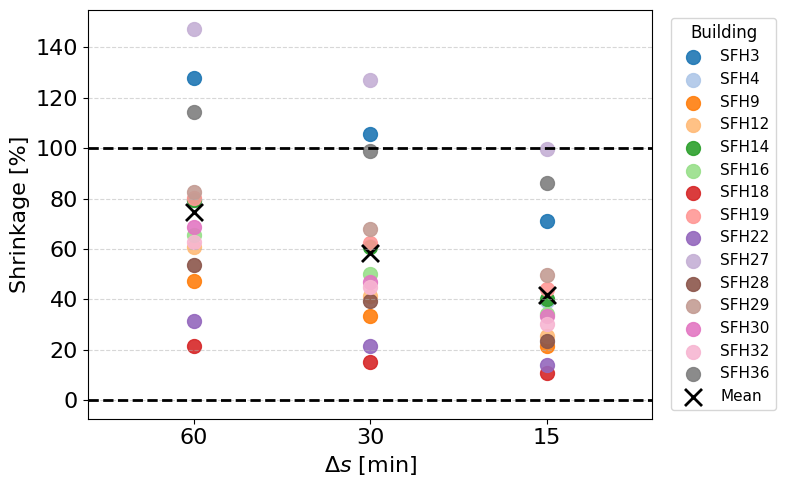

In [ ]:
def plot_shrinkage_by_experiment_matplotlib(df: pd.DataFrame,
                                            experiments=(60, 30, 15),
                                            show_summary=True,
                                            summary_stat="median"):
    """
    Matplotlib version: scatter plot of shrinkage vs experiment.
    """
    df_ = df.reset_index().rename(columns={df.index.name or 'index': 'building'})
    rows, order = [], []

    plt.rcParams.update({
        "font.size":            11,
        "axes.labelsize":       16,
        "xtick.labelsize":      16,
        "ytick.labelsize":      16,
        "legend.fontsize":      9,    # labels
        "legend.title_fontsize":10    # title matches labels
    })

    for i, e in enumerate(experiments):
        col = f'shrinkage_{e}'
        if col not in df_.columns:
            continue
        order.append(e)
        base = float(i)
        for _, r in df_.iterrows():
            val = r[col] * 100
            if pd.isna(val):
                continue
            rows.append({
                "x": base ,#+ _stable_jitter(f"{r['building']}|{e}", scale=jitter),
                "x_base": base,
                "experiment": f"{e}-min",
                "building": r["building"],
                "shrinkage": float(val),
            })

    long_df = pd.DataFrame(rows)
    if long_df.empty:
        raise ValueError("No shrinkage_* columns found for the given experiments.")

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 5))

    # Pick a color per building
    buildings = long_df['building'].unique()
    cmap = plt.get_cmap("tab20")
    colors = {b: cmap(i % 20) for i, b in enumerate(buildings)}

    # Scatter for each building
    for b in buildings:
        df_b = long_df[long_df['building'] == b]
        ax.scatter(df_b["x"], df_b["shrinkage"], label=b, color=colors[b], alpha=0.9, s=100)

    # Reference lines
    ax.axhline(0, color="black", linestyle="--", linewidth=2)
    ax.axhline(100, color="black", linestyle="--", linewidth=2)

    # Optional summary
    if show_summary:
        if summary_stat == "median":
            agg = long_df.groupby("x_base")["shrinkage"].median()
            label = "Median"
        else:
            agg = long_df.groupby("x_base")["shrinkage"].mean()
            label = "Mean"
        ax.scatter(agg.index, agg.values,
                   marker="x", color="black", s=150, linewidths=2, label=label)

    # Formatting
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{e}" for e in order])
    ax.set_xlim(-0.6, len(order)-0.4)
    ax.set_ylabel("Shrinkage [%]")
    ax.set_xlabel(r"$\Delta s$ [min]")
    #ax.set_title("Shrinkage of each building/experiment pair")
    ax.legend(title="Building", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11, title_fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.5)


    plt.tight_layout()
    return fig, long_df


# --- Usage example ---
fig, tidy = plot_shrinkage_by_experiment_matplotlib(comparison_df, summary_stat="mean")
#fig.savefig("shrinkage_by_experiment_v2.pdf", bbox_inches="tight")
plt.show()


## 4 - Shrinkage with decreasing battery degradation costs

In [ ]:
time_of_executions = ["2026-01-31_13-03"]  # f60-gt60-c4

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref60_gt60_c4 = MultiRunEvaluator(run_paths=csvs)
mref60_gt60_c4.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,60.0,1179.81,248.50,1113.34,166.95,3294.82,1644.03,69.05,9.97,81.56,79.60,148.65,1.0
1,rule-based,15,15,60.0,1132.74,322.04,1122.48,120.93,989.77,496.66,20.86,0.32,201.11,201.05,221.91,2.0


In [ ]:
time_of_executions = ["2026-01-31_13-12"]  # f60-gt1-c4

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref60_gt1_c4 = MultiRunEvaluator(run_paths=csvs)
mref60_gt1_c4.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,60.0,1193.84,253.85,1119.84,167.63,3670.2,1831.71,76.93,9.91,86.22,84.28,161.21,1.0
1,rule-based,15,15,60.0,1139.61,323.93,1125.71,121.54,1170.7,587.12,24.66,0.31,202.39,202.33,226.99,2.0


In [ ]:
time_of_executions = ["2026-01-31_13-17"]  # f60-gt60-c2

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref60_gt60_c2 = MultiRunEvaluator(run_paths=csvs)
mref60_gt60_c2.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,60.0,1179.46,248.42,1113.03,166.91,3295.12,1644.20,34.53,9.93,81.51,79.57,114.09,1.0
1,rule-based,15,15,60.0,1132.74,322.04,1122.48,120.93,989.77,496.66,10.43,0.32,201.11,201.05,211.48,2.0


In [ ]:
time_of_executions = ["2026-01-31_13-18"]  # f60-gt1-c2

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref60_gt1_c2 = MultiRunEvaluator(run_paths=csvs)
mref60_gt1_c2.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,60.0,1193.75,253.84,1119.59,167.59,3673.7,1833.41,38.50,10.00,86.25,84.29,122.79,1.0
1,rule-based,15,15,60.0,1139.61,323.93,1125.71,121.54,1170.7,587.12,12.33,0.31,202.39,202.33,214.66,2.0


In [ ]:
time_of_executions = ["2026-02-02_08-54"]  # f60-gt60-c0

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref60_gt60_c0 = MultiRunEvaluator(run_paths=csvs)
mref60_gt60_c0.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,60.0,1179.08,248.44,1112.79,166.78,3293.00,1643.19,0.0,9.82,81.66,79.73,79.73,1.0
1,rule-based,15,15,60.0,1132.74,322.04,1122.48,120.93,989.77,496.66,0.0,0.32,201.11,201.05,201.05,2.0


In [ ]:
time_of_executions = ["2026-02-02_08-55"]  # f60-gt1-c0

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref60_gt1_c0 = MultiRunEvaluator(run_paths=csvs)
mref60_gt1_c0.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,60.0,1192.95,253.70,1118.82,167.37,3678.01,1835.62,0.0,9.90,86.33,84.39,84.39,1.0
1,rule-based,15,15,60.0,1139.61,323.93,1125.71,121.54,1170.70,587.12,0.0,0.31,202.39,202.33,202.33,2.0


In [ ]:
time_of_executions = ["2026-01-31_18-59"]  # f30-gt30-c4

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref30_gt30_c4 = MultiRunEvaluator(run_paths=csvs)
mref30_gt30_c4.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,30.0,1181.40,249.13,1114.07,166.95,3338.25,1665.75,69.96,9.95,82.18,80.23,150.19,1.0
1,rule-based,15,15,30.0,1135.01,322.61,1123.68,121.23,1042.86,523.20,21.97,0.32,201.38,201.32,223.29,2.0


In [ ]:
time_of_executions = ["2026-01-31_19-00"]  # f30-gt1-c4

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref30_gt1_c4 = MultiRunEvaluator(run_paths=csvs)
mref30_gt1_c4.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,30.0,1190.89,252.91,1117.76,167.33,3626.62,1809.92,76.02,9.92,85.57,83.63,159.64,1.0
1,rule-based,15,15,30.0,1139.61,323.93,1125.71,121.54,1170.70,587.12,24.66,0.31,202.39,202.33,226.99,2.0


In [ ]:
time_of_executions = ["2026-01-31_19-02", "2026-02-01_16-00"]  # f30-gt30-c2

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref30_gt30_c2 = MultiRunEvaluator(run_paths=csvs)
mref30_gt30_c2.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,30.0,1181.28,249.11,1113.96,166.93,3338.13,1665.7,34.98,9.94,82.18,80.23,115.21,1.0
1,rule-based,15,15,30.0,1135.01,322.61,1123.68,121.23,1042.86,523.2,10.99,0.32,201.38,201.32,212.30,2.0


In [ ]:
time_of_executions = ["2026-01-31_19-03", "2026-02-01_15-58"]  # f30-gt1-c2

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref30_gt1_c2 = MultiRunEvaluator(run_paths=csvs)
mref30_gt1_c2.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,30.0,1190.87,252.92,1117.69,167.32,3630.22,1811.73,38.05,9.91,85.60,83.66,121.70,1.0
1,rule-based,15,15,30.0,1139.61,323.93,1125.71,121.54,1170.70,587.12,12.33,0.31,202.39,202.33,214.66,2.0


In [ ]:
time_of_executions = ["2026-02-02_09-01"]  # f30-gt30-c0

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref30_gt30_c0 = MultiRunEvaluator(run_paths=csvs)
mref30_gt30_c0.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,30.0,1180.42,248.94,1113.14,166.77,3338.64,1665.98,0.0,9.89,82.16,80.23,80.23,1.0
1,rule-based,15,15,30.0,1135.01,322.61,1123.68,121.23,1042.86,523.20,0.0,0.32,201.38,201.32,201.32,2.0


In [ ]:
time_of_executions = ["2026-02-02_09-03"]  # f30-gt1-c0

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref30_gt1_c0 = MultiRunEvaluator(run_paths=csvs)
mref30_gt1_c0.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,30.0,1189.83,252.70,1116.56,167.12,3637.6,1815.45,0.0,9.84,85.58,83.65,83.65,1.0
1,rule-based,15,15,30.0,1139.61,323.93,1125.71,121.54,1170.7,587.12,0.0,0.31,202.39,202.33,202.33,2.0


In [ ]:
time_of_executions = ["2026-02-01_16-03"]  # f15-gt15-c4

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref15_gt15_c4 = MultiRunEvaluator(run_paths=csvs)
mref15_gt15_c4.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,15.0,1182.91,249.75,1114.73,166.98,3380.94,1687.10,70.86,9.93,82.76,80.82,151.67,1.0
1,rule-based,15,15,15.0,1136.74,323.08,1124.43,121.37,1091.44,547.49,22.99,0.31,201.71,201.65,224.65,2.0


In [ ]:
time_of_executions = ["2026-02-03_09-23"]  # f15-gt1-c4

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref15_gt1_c4 = MultiRunEvaluator(run_paths=csvs)
mref15_gt1_c4.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,15.0,1188.83,252.20,1116.85,167.20,3568.69,1780.95,74.80,9.94,85.00,83.05,157.85,1.0
1,rule-based,15,15,15.0,1139.61,323.93,1125.71,121.54,1170.70,587.12,24.66,0.31,202.39,202.33,226.99,2.0


In [ ]:
time_of_executions = ["2026-02-03_09-26"]  # f15-gt15-c2

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref15_gt15_c2 = MultiRunEvaluator(run_paths=csvs)
mref15_gt15_c2.leaderboard_mean()


,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,15.0,1182.94,249.74,1114.79,166.98,3380.79,1687.04,35.43,9.90,82.76,80.82,116.25,1.0
1,rule-based,15,15,15.0,1136.74,323.08,1124.43,121.37,1091.44,547.49,11.50,0.31,201.71,201.65,213.15,2.0


In [ ]:
time_of_executions = ["2026-02-03_09-31"]  # f15-gt1-c2

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref15_gt1_c2 = MultiRunEvaluator(run_paths=csvs)
mref15_gt1_c2.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,15.0,1188.73,252.19,1116.73,167.18,3571.79,1782.52,37.43,9.90,85.01,83.07,120.51,1.0
1,rule-based,15,15,15.0,1139.61,323.93,1125.71,121.54,1170.70,587.12,12.33,0.31,202.39,202.33,214.66,2.0


In [ ]:
time_of_executions = ["2026-02-05_08-41", "2026-02-06_20-09", "2026-02-07_08-51"]  # f15-gt15-c0

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref15_gt15_c0 = MultiRunEvaluator(run_paths=csvs)
mref15_gt15_c0.leaderboard_mean()


,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal,15,15,15.0,1182.24,249.65,1114.15,166.83,3381.10,1687.22,0.0,9.85,82.82,80.89,80.89,1.0
1,rule-based,15,15,15.0,1136.74,323.08,1124.43,121.37,1091.44,547.49,0.0,0.31,201.71,201.65,201.65,2.0


In [ ]:
time_of_executions = ["2026-02-05_08-44"]  # f15-gt1-c0

csvs = [p for t in time_of_executions for p in Path("../runs").rglob(f"logs_{t}*.csv")]
csvs = sorted(csvs,key=lambda p: int(re.search(r"SFH(\d+)", p.name).group(1)))
mref15_gt1_c0 = MultiRunEvaluator(run_paths=csvs)
mref15_gt1_c0.leaderboard_mean()

,model,runs,buildings,freq,e_import_total,import_cost,e_export_total,export_revenue,e_throughput,e_discharged_total,e_battery_deg_costs,e_end,net_cost,net_cost_adj,net_cost_final,avg_rank
0,ideal_rule_constGrid,15,15,15.0,1187.70,251.98,1115.57,166.96,3579.9,1786.59,0.0,9.86,85.02,83.08,83.08,1.0
1,rule-based,15,15,15.0,1139.61,323.93,1125.71,121.54,1170.7,587.12,0.0,0.31,202.39,202.33,202.33,2.0


In [ ]:
import pandas as pd

def get_shrinkage_battery_deg():
    """
    Evaluates simulation results by comparing ideal vs rule-based models.
    Returns a dataframe with variable names and cost improvements.
    """
    results = []
    
    # Define parameter ranges
    xx_values = [60, 30, 15]
    z_values = [8, 4, 2, 0]    
    #xx_values = [60]
    #z_values = [4]
    
    for xx in xx_values:
        yy_values = [1, xx]  # YY can be 1 or XX
        
        for yy in yy_values:
            for z in z_values:
                var_name = f"mref{xx}_gt{yy}_c{z}"
                
                try:
                    # Try to get the dataframe from globals
                    df = globals().get(var_name).leaderboard_mean()
                    
                    if df is None:
                        continue
                    
                    # Determine which ideal model to use
                    if yy == xx:
                        ideal_model_name = "ideal"
                    else:  # yy == 1
                        ideal_model_name = "ideal_rule_constGrid"
                    
                    # Extract net_cost_final values
                    df_model = df.set_index("model")
                    rule_based_cost = df_model.loc["rule-based", "net_cost_final"]
                    ideal_cost = df_model.loc[ideal_model_name, "net_cost_final"]

                    #print(f"Comparing {var_name}: rule-based={rule_based_cost}, ideal={ideal_cost}")
                    
                    # Calculate absolute improvement
                    improvement = abs(rule_based_cost - ideal_cost)
                    
                    results.append({
                        'variable': var_name,
                        'cost_improvement': improvement
                    })
                    
                except (KeyError, AttributeError, TypeError) as e:
                    # Variable exists but model/column not found or wrong type
                    print(f"Skipping {var_name}: {type(e).__name__}")
                    continue
    
    # Create dataframe from results
    results_df = pd.DataFrame(results)
    results_df = results_df.set_index('variable')
    
    return results_df

# Call the function
results_df = get_shrinkage_battery_deg()
print(results_df)

                cost_improvement
variable                        
mref60_gt1_c8               9.46
mref60_gt1_c4              65.78
mref60_gt1_c2              91.87
mref60_gt1_c0             117.94
mref60_gt60_c8             30.46
mref60_gt60_c4             73.26
mref60_gt60_c2             97.39
mref60_gt60_c0            121.32
mref30_gt1_c8              14.25
mref30_gt1_c4              67.35
mref30_gt1_c2              92.96
mref30_gt1_c0             118.68
mref30_gt30_c8             30.44
mref30_gt30_c4             73.10
mref30_gt30_c2             97.09
mref30_gt30_c0            121.09
mref15_gt1_c8              19.16
mref15_gt1_c4              69.14
mref15_gt1_c2              94.15
mref15_gt1_c0             119.25
mref15_gt15_c8             30.45
mref15_gt15_c4             72.98
mref15_gt15_c2             96.90
mref15_gt15_c0            120.76


In [ ]:
def calculate_shrinkage(results_df):
    """
    Calculate shrinkage between gt1 and gtXX pairs.
    Shrinkage = (1 - val_of_gt1 / val_of_gtXX) * 100
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with variable names as index and cost_improvement column
    
    Returns:
    --------
    pd.DataFrame with shrinkage values in percent
    """
    shrinkage_results = []
    
    xx_values = [60, 30, 15]
    z_values = [8, 4, 2, 0]
    
    for xx in xx_values:
        for z in z_values:
            # Construct the two variable names
            var_gtXX = f"mref{xx}_gt{xx}_c{z}"
            var_gt1 = f"mref{xx}_gt1_c{z}"
            
            try:
                # Check if both variables exist in results
                if var_gtXX not in results_df.index or var_gt1 not in results_df.index:
                    continue
                
                # Get the cost improvement values
                val_gtXX = results_df.loc[var_gtXX, 'cost_improvement']
                val_gt1 = results_df.loc[var_gt1, 'cost_improvement']
                
                # Calculate shrinkage (in percent)
                shrinkage = (1 - val_gt1 / val_gtXX) * 100
                
                shrinkage_results.append({
                    'config': f"mref{xx}_c{z}",
                    'gtXX_value': val_gtXX,
                    'gt1_value': val_gt1,
                    'shrinkage_percent': shrinkage
                })
                
            except (KeyError, ZeroDivisionError) as e:
                print(f"Skipping mref{xx}_c{z}: {type(e).__name__}")
                continue
    
    # Create dataframe from results
    shrinkage_df = pd.DataFrame(shrinkage_results)
    shrinkage_df = shrinkage_df.set_index('config')
    
    return shrinkage_df

shrinkage_df = calculate_shrinkage(results_df)
print("Shrinkage Analysis:")
print(shrinkage_df)

Shrinkage Analysis:
           gtXX_value  gt1_value  shrinkage_percent
config                                             
mref60_c8       30.46       9.46          68.942876
mref60_c4       73.26      65.78          10.210210
mref60_c2       97.39      91.87           5.667933
mref60_c0      121.32     117.94           2.786020
mref30_c8       30.44      14.25          53.186597
mref30_c4       73.10      67.35           7.865937
mref30_c2       97.09      92.96           4.253785
mref30_c0      121.09     118.68           1.990255
mref15_c8       30.45      19.16          37.077176
mref15_c4       72.98      69.14           5.261716
mref15_c2       96.90      94.15           2.837977
mref15_c0      120.76     119.25           1.250414


In [ ]:
# Save the dataframe
#shrinkage_df.to_csv('shrinkage_results_battery_deg.csv')

# Load it back later
#shrinkage_df = pd.read_csv('shrinkage_results_battery_deg.csv', index_col='config')


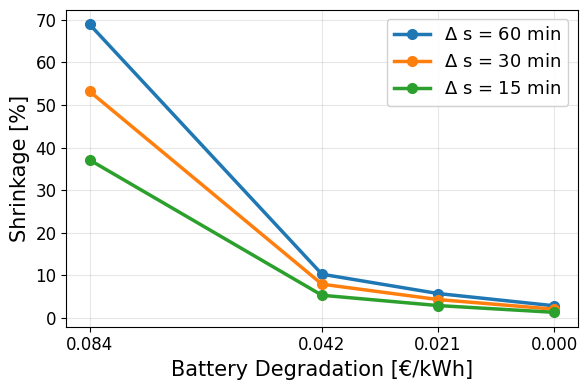

In [ ]:
import matplotlib.pyplot as plt


def plot_shrinkage(shrinkage_df):
    """
    Plot shrinkage vs Z value for different XX values.
    Paper-ready version with reversed x-axis.
    """
    # Parse the config to extract XX and Z values
    plot_data = {}
    z_values = [0.084, 0.042, 0.021, 0]
    for i, config in enumerate(shrinkage_df.index):
        # Extract XX and Z from config like "mref60_c4"
        parts = config.split('_')
        xx = int(parts[0].replace('mref', ''))
        z = int(parts[1].replace('c', '')) * 0.01
        if z == 0.08:
            z = 0.084  # Adjust for the specific case of c8
        elif z == 0.04:
            z = 0.042  # Adjust for the specific case of c4
        elif z == 0.02:
            z = 0.021  # Adjust for the specific case of c2
        
        if xx not in plot_data:
            plot_data[xx] = {'z': [], 'shrinkage': []}
        
        plot_data[xx]['z'].append(z)
        plot_data[xx]['shrinkage'].append(shrinkage_df.loc[config, 'shrinkage_percent'])
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(6, 4))
    
    for xx in sorted(plot_data.keys(), reverse=True):  # 60, 30, 15
        # Sort by Z value for proper line connection
        z_vals = plot_data[xx]['z']
        shrinkage_vals = plot_data[xx]['shrinkage']
        sorted_pairs = sorted(zip(z_vals, shrinkage_vals), reverse=True)
        z_sorted, shrinkage_sorted = zip(*sorted_pairs)
        
        ax.plot(z_sorted, shrinkage_sorted, marker='o', linewidth=2.5, 
                markersize=7, label=rf"$\Delta$ s = {xx} min")
    
    ax.set_xlabel('Battery Degradation [€/kWh]', fontsize=15)
    ax.set_ylabel('Shrinkage [%]', fontsize=15)
    ax.legend(fontsize=13, framealpha=0.9)
    ax.grid(True, alpha=0.3, linewidth=0.8)
    ax.set_xticks([0.084, 0.042, 0.021, 0])
    ax.tick_params(axis='both', labelsize=12)
    
    # Reverse x-axis
    ax.invert_xaxis()
    
    plt.tight_layout()
    #plt.savefig('shrinkage_battery_deg.pdf', bbox_inches='tight')
    plt.show()


# Call the function
plot_shrinkage(shrinkage_df)
